# Which Policyholders Will Cost the Most?
**GLM Tweedie · LightGBM · XGBoost · Random Forest · SHAP · Binary Classification**

Insurance companies price policies based on limited information at onboarding, with no reliable way to predict which customers will generate the highest claims. This project built and compared models to identify high-risk policyholders before a claim is filed.

**Two tasks:**
- **Task 1 (Regression):** Predict Loss Cost (LC) and Historical Adjusted Loss Cost (HALC)
- **Task 2 (Classification):** Predict whether a policyholder will file a claim (CS)

## 1. Setup & Imports

In [18]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    mean_squared_error, roc_auc_score,
    recall_score, precision_score, f1_score, roc_curve
)
from sklearn.linear_model import TweedieRegressor, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
import shap

warnings.filterwarnings('ignore')

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

for old_file in [
    'model_comparison_halc.png', 'roc_curve_comparison.png',
    'shap_halc.png', 'shap_cs.png',
    'predicted_vs_actual_halc.png', 'residuals_halc.png',
    'predicted_vs_actual_lc.png', 'residuals_lc.png',
    'residuals_vs_predicted_lc.png', 'residuals_vs_predicted_halc.png',
    'segment_avg_halc.png', 'class_distribution.png', 'prediction_breakdown_pie.png'
]:
    p = os.path.join(PLOTS_DIR, old_file)
    if os.path.exists(p): os.remove(p)

print('Setup complete.')


Setup complete.


## 2. Visual Style

In [19]:
LIME  = "#c8ff00"
PINK  = "#ff69b4"
WHITE = "#ffffff"
BG    = "#0a0a0a"
GRAY  = "#333333"
MGRAY = "#1a1a1a"

sns.set_style("dark", {"axes.facecolor": BG, "figure.facecolor": BG})

plt.rcParams.update({
    "figure.figsize":   (10, 6),
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GRAY,
    "axes.labelcolor":  WHITE,
    "xtick.color":      WHITE,
    "ytick.color":      WHITE,
    "text.color":       WHITE,
    "axes.titleweight": "bold",
    "axes.titlesize":   14,
    "axes.labelsize":   11,
    "legend.facecolor": BG,
    "legend.edgecolor": GRAY,
    "legend.labelcolor": WHITE,
})

def apply_style(ax):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.grid(True, axis="y", color=MGRAY, linewidth=0.8)
    ax.grid(False, axis="x")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(GRAY)
    ax.spines["bottom"].set_color(GRAY)

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close()

print("Style ready.")

Style ready.


## 3. Load Dataset

> Upload `insurance_train.csv` to `/content/` before running this cell.

In [20]:
df_train = pd.read_csv('/content/sample_data/insurance_train.csv')
pd.set_option('display.max_columns', None)
print('Train shape:', df_train.shape)
print('Missing values:')
print(df_train.isnull().sum())

Train shape: (37451, 28)
Missing values:
X.1       0
X.2       0
X.3       0
X.4       0
X.5       0
X.6       0
X.7       0
X.8       0
X.9       0
X.10      0
X.11      0
X.12      0
X.13      0
X.14      0
X.15      0
X.16      0
X.17      0
X.18      0
X.19      0
X.20      0
X.21      0
X.22      0
X.23      0
X.24      0
X.25      0
X.26      0
X.27    593
X.28      0
dtype: int64


## 4. Data Cleaning & Feature Engineering

In [21]:
# ------------------------------------------------------------
# Build target variables
# ------------------------------------------------------------
df_train['CS']   = (df_train['X.16'] > 0).astype(int)   # claim occurred: binary
df_train['LC']   = 0.0
df_train['HALC'] = 0.0

nonzero = df_train['X.16'] > 0
df_train.loc[nonzero, 'LC']   = df_train.loc[nonzero, 'X.15'] / df_train.loc[nonzero, 'X.16']
df_train.loc[nonzero, 'HALC'] = df_train.loc[nonzero, 'LC'] * df_train.loc[nonzero, 'X.18']

# Drop leakage columns
cols_to_drop = ['X.1', 'X.15', 'X.16', 'X.17', 'X.18']
df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], inplace=True)

# ------------------------------------------------------------
# Parse dates and engineer features
# ------------------------------------------------------------
date_cols = ['X.2', 'X.3', 'X.4', 'X.5', 'X.6']
for col in date_cols:
    df_train[col] = pd.to_datetime(df_train[col], errors='coerce', dayfirst=True)

df_train['vehicle_age']                 = 2020 - df_train['X.22']
df_train['age']                         = 2020 - df_train['X.5'].dt.year
df_train['driving_experience']          = 2020 - df_train['X.6'].dt.year
df_train['policy_duration_days']        = (df_train['X.4'] - df_train['X.2']).dt.days
df_train['time_since_last_renewal_days']= (df_train['X.3'] - df_train['X.2']).dt.days

df_train.drop(columns=date_cols, inplace=True)

# One-hot encode categoricals
categorical_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21', 'X.27']
df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)

print('Cleaned dataset shape:', df_train.shape)
print('\nTarget distributions:')
print(f'  CS (claim occurred): {df_train["CS"].value_counts().to_dict()}')
print(f'  LC mean (nonzero): {df_train.loc[df_train["LC"]>0, "LC"].mean():.2f}')
print(f'  HALC mean (nonzero): {df_train.loc[df_train["HALC"]>0, "HALC"].mean():.2f}')

Cleaned dataset shape: (37451, 28)

Target distributions:
  CS (claim occurred): {0: 33300, 1: 4151}
  LC mean (nonzero): 629.84
  HALC mean (nonzero): 1160.93


## 5. Task 1 — Regression: Predict Loss Cost

**Q: Which model best predicts LC and HALC before a claim is filed?**

Six models compared: GLM Tweedie, Random Forest, Gradient Boosting, LightGBM, XGBoost, Neural Network.

In [22]:
# ------------------------------------------------------------
# Prepare regression dataset
# ------------------------------------------------------------
df = df_train.copy()
drop_cols = ['LC', 'HALC', 'CS']

# Filter extreme outliers (0.1% tails)
q_lc   = df['LC'].quantile([0.001, 0.999])
q_halc = df['HALC'].quantile([0.001, 0.999])
df_filtered = df[
    (df['LC']   >= q_lc.iloc[0])   & (df['LC']   <= q_lc.iloc[1]) &
    (df['HALC'] >= q_halc.iloc[0]) & (df['HALC'] <= q_halc.iloc[1])
]

X      = df_filtered.drop(columns=drop_cols)
y_lc   = df_filtered['LC']
y_halc = df_filtered['HALC']

X_train_lc,   X_val_lc,   y_train_lc,   y_val_lc   = train_test_split(X, y_lc,   test_size=0.2, random_state=42)
X_train_halc, X_val_halc, y_train_halc, y_val_halc = train_test_split(X, y_halc, test_size=0.2, random_state=42)

# Scale for GLM and MLP
scaler_lc   = StandardScaler().fit(X_train_lc)
scaler_halc = StandardScaler().fit(X_train_halc)
X_train_lc_s   = scaler_lc.transform(X_train_lc)
X_val_lc_s     = scaler_lc.transform(X_val_lc)
X_train_halc_s = scaler_halc.transform(X_train_halc)
X_val_halc_s   = scaler_halc.transform(X_val_halc)

print(f'Regression dataset: {len(df_filtered):,} policyholders')

Regression dataset: 37,402 policyholders


In [23]:
# ------------------------------------------------------------
# Train and compare all regression models
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

# GLM Tweedie
print('Fitting GLM Tweedie...')
glm_lc   = TweedieRegressor(power=1.5, link='log', alpha=0.0, max_iter=1000)
glm_halc = TweedieRegressor(power=1.5, link='log', alpha=0.0, max_iter=1000)
glm_lc.fit(X_train_lc_s, y_train_lc)
glm_halc.fit(X_train_halc_s, y_train_halc)
results.append({'Model': 'GLM Tweedie',
    'LC RMSE':   rmse(y_val_lc,   glm_lc.predict(X_val_lc_s)),
    'HALC RMSE': rmse(y_val_halc, glm_halc.predict(X_val_halc_s))})

# Random Forest
print('Fitting Random Forest...')
rf_lc   = RandomForestRegressor(n_estimators=100, random_state=42)
rf_halc = RandomForestRegressor(n_estimators=100, random_state=42)
rf_lc.fit(X_train_lc, y_train_lc)
rf_halc.fit(X_train_halc, y_train_halc)
results.append({'Model': 'Random Forest',
    'LC RMSE':   rmse(y_val_lc,   rf_lc.predict(X_val_lc)),
    'HALC RMSE': rmse(y_val_halc, rf_halc.predict(X_val_halc))})

# Gradient Boosting
print('Fitting Gradient Boosting...')
gb_lc   = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_halc = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_lc.fit(X_train_lc, y_train_lc)
gb_halc.fit(X_train_halc, y_train_halc)
results.append({'Model': 'Gradient Boosting',
    'LC RMSE':   rmse(y_val_lc,   gb_lc.predict(X_val_lc)),
    'HALC RMSE': rmse(y_val_halc, gb_halc.predict(X_val_halc))})

# LightGBM
print('Fitting LightGBM...')
lgb_lc   = LGBMRegressor(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42)
lgb_halc = LGBMRegressor(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42)
lgb_lc.fit(X_train_lc, y_train_lc)
lgb_halc.fit(X_train_halc, y_train_halc)
results.append({'Model': 'LightGBM',
    'LC RMSE':   rmse(y_val_lc,   lgb_lc.predict(X_val_lc)),
    'HALC RMSE': rmse(y_val_halc, lgb_halc.predict(X_val_halc))})

# XGBoost
print('Fitting XGBoost...')
xgb_lc   = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_halc = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_lc.fit(X_train_lc, y_train_lc)
xgb_halc.fit(X_train_halc, y_train_halc)
results.append({'Model': 'XGBoost',
    'LC RMSE':   rmse(y_val_lc,   xgb_lc.predict(X_val_lc)),
    'HALC RMSE': rmse(y_val_halc, xgb_halc.predict(X_val_halc))})

# Neural Network
print('Fitting Neural Network...')
nn_lc   = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
nn_halc = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
nn_lc.fit(X_train_lc_s, y_train_lc)
nn_halc.fit(X_train_halc_s, y_train_halc)
results.append({'Model': 'Neural Network',
    'LC RMSE':   rmse(y_val_lc,   nn_lc.predict(X_val_lc_s)),
    'HALC RMSE': rmse(y_val_halc, nn_halc.predict(X_val_halc_s))})

results_df = pd.DataFrame(results).round(2).sort_values('HALC RMSE')
print('\n' + '=' * 60)
print('REGRESSION MODEL COMPARISON (HALC)')
print('=' * 60)
print(results_df.to_string(index=False))

Fitting GLM Tweedie...
Fitting Random Forest...
Fitting Gradient Boosting...
Fitting LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1935
[LightGBM] [Info] Number of data points in the train set: 29921, number of used features: 25
[LightGBM] [Info] Start training from score 51.995538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

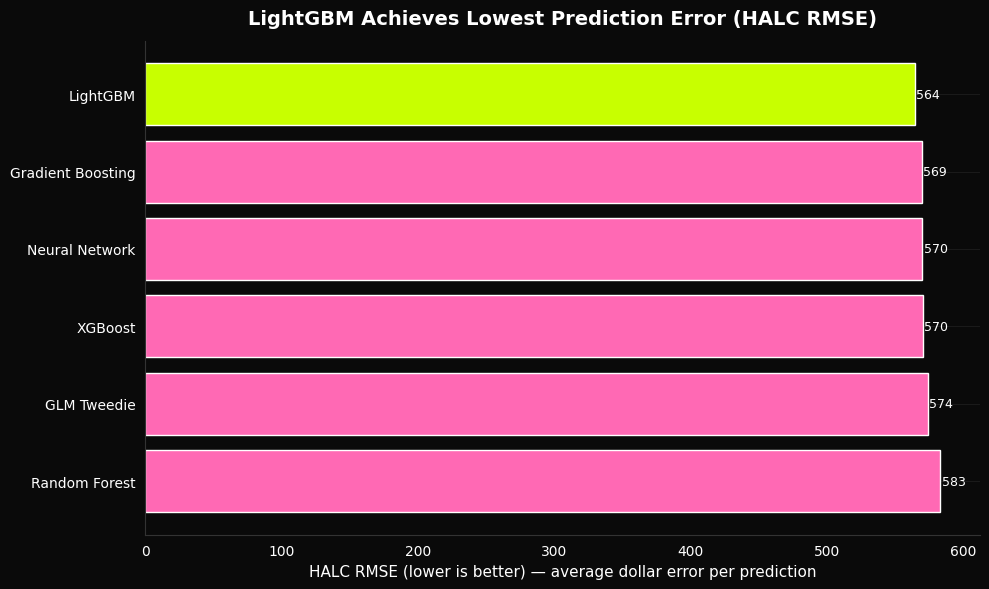

In [24]:
# Model comparison — HALC RMSE with value labels
fig, ax = plt.subplots()
colors = [LIME if m == results_df.iloc[0]["Model"] else PINK for m in results_df["Model"]]
bars = ax.barh(results_df["Model"], results_df["HALC RMSE"], color=colors)
for bar, val in zip(bars, results_df["HALC RMSE"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", ha="left", color=WHITE, fontsize=9)
ax.set_title("LightGBM Achieves Lowest Prediction Error (HALC RMSE)", pad=12)
ax.set_xlabel("HALC RMSE (lower is better) — average dollar error per prediction")
ax.invert_yaxis()
apply_style(ax)
save_plot("model_comparison_halc.png")


## 6. Task 1 — SHAP Feature Importance

In [25]:
final_lgbm = LGBMRegressor(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42)
final_lgbm.fit(X, y_halc)
explainer_halc   = shap.Explainer(final_lgbm)
shap_values_halc = explainer_halc(X)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 37402, number of used features: 25
[LightGBM] [Info] Start training from score 92.498256
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

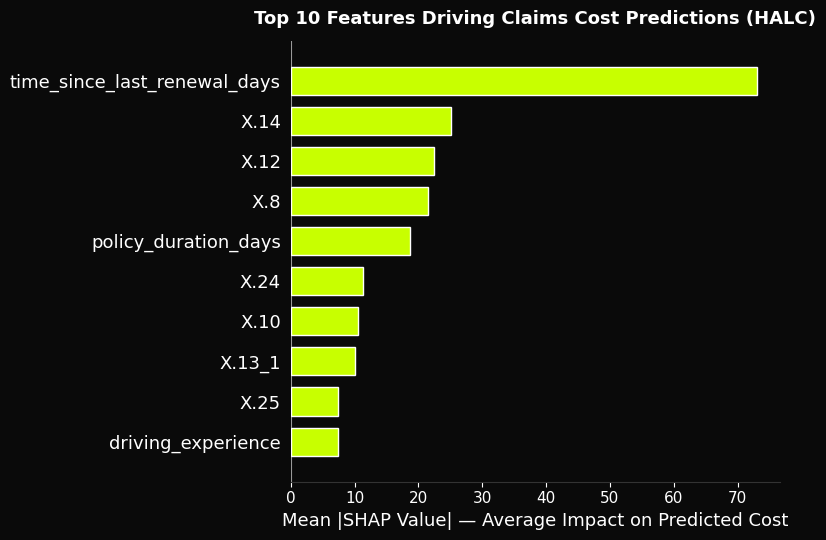

In [26]:
plt.rcParams.update({"text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE,
    "figure.facecolor": BG, "axes.facecolor": BG})

plt.figure(facecolor=BG)
shap.summary_plot(shap_values_halc, X, plot_type="bar", show=False, max_display=10, color=LIME)
plt.gcf().set_facecolor(BG)
plt.gca().set_facecolor(BG)
plt.gca().tick_params(colors=WHITE)
plt.title("Top 10 Features Driving Claims Cost Predictions (HALC)", color=WHITE, pad=12, fontsize=13, fontweight="bold")
plt.xlabel("Mean |SHAP Value| — Average Impact on Predicted Cost", color=WHITE)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_halc.png"), dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()
plt.close()

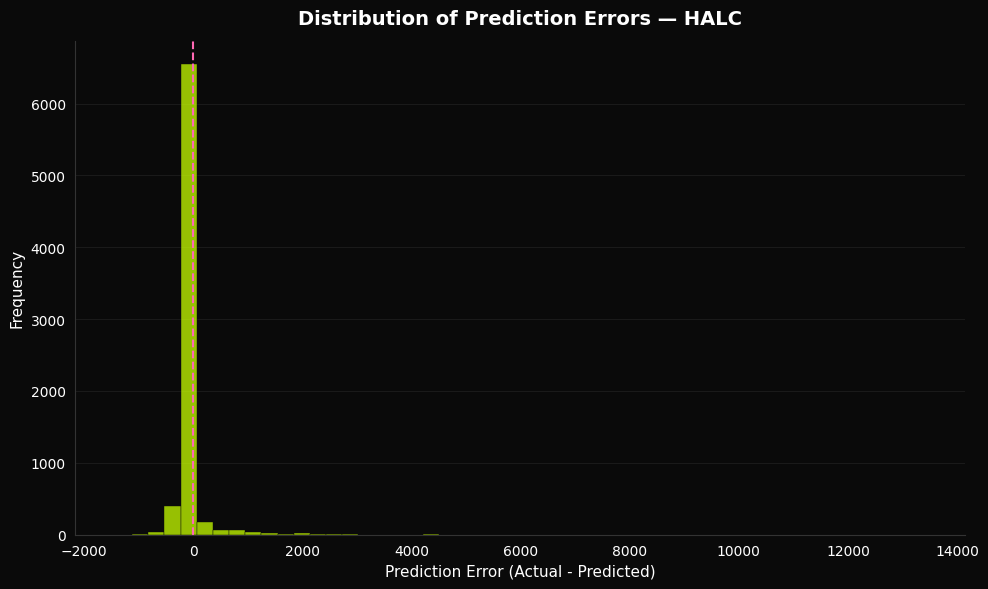

In [31]:
# Residuals distribution
residuals = y_val_halc.values[:len(y_pred_halc)] - y_pred_halc

fig, ax = plt.subplots()
sns.histplot(residuals, bins=50, color=LIME, edgecolor=BG, linewidth=0.3, ax=ax)
ax.axvline(0, color=PINK, linestyle='--', linewidth=1.5)
ax.set_title('Distribution of Prediction Errors — HALC', pad=12)
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Frequency')
apply_style(ax)
save_plot('residuals_halc.png')

## 7. Customer Risk Segmentation

CUSTOMER RISK SEGMENTATION BY TENURE
                Segment   Avg HALC
         New\n(0-2 yrs)  88.664564
    Emerging\n(3-5 yrs) 104.663985
Established\n(6-10 yrs) 320.161407
       Loyal\n(11+ yrs)  15.831083


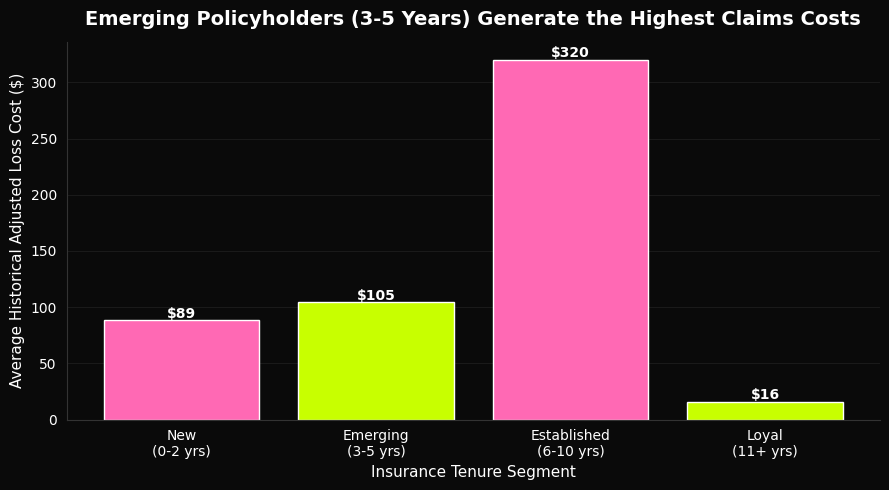

In [32]:
tenure_col = "X.9" if "X.9" in X.columns else X.columns[0]

seg_df = X_val_halc.copy()
seg_df["y_true"] = y_val_halc.values
seg_df["y_pred"] = y_pred_halc

if tenure_col in seg_df.columns:
    bins   = [0, 2, 5, 10, 100]
    labels = ["New\n(0-2 yrs)", "Emerging\n(3-5 yrs)", "Established\n(6-10 yrs)", "Loyal\n(11+ yrs)"]
    seg_df["segment"] = pd.cut(seg_df[tenure_col], bins=bins, labels=labels, right=True)
    seg_summary = seg_df.groupby("segment", observed=True)["y_true"].mean().reset_index()
    seg_summary.columns = ["Segment", "Avg HALC"]

    print("CUSTOMER RISK SEGMENTATION BY TENURE")
    print(seg_summary.to_string(index=False))

    bar_colors = [PINK, LIME, PINK, LIME]
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(seg_summary["Segment"], seg_summary["Avg HALC"], color=bar_colors)
    for bar, val in zip(bars, seg_summary["Avg HALC"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"${val:.0f}", ha="center", color=WHITE, fontsize=10, fontweight="bold")
    ax.set_title("Emerging Policyholders (3-5 Years) Generate the Highest Claims Costs", pad=12)
    ax.set_xlabel("Insurance Tenure Segment")
    ax.set_ylabel("Average Historical Adjusted Loss Cost ($)")
    apply_style(ax)
    save_plot("segment_avg_halc.png")
else:
    print(f"Tenure column not found. Available: {list(X.columns[:10])}")


## 8. Task 2 — Classification: Predict Claim Occurrence

**Q: Can we predict whether a policyholder will file a claim at all?**

In [33]:
# Prepare classification dataset
X_cs = df_train.drop(columns=['CS', 'HALC', 'LC'])
y_cs = df_train['CS']

X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(X_cs, y_cs, test_size=0.2, random_state=42)

scaler_cs = StandardScaler()
X_train_s = scaler_cs.fit_transform(X_train_cs)
X_test_s  = scaler_cs.transform(X_test_cs)

print('Classification dataset ready.')
print(f'Train size: {len(X_train_cs):,} | Test size: {len(X_test_cs):,}')
print(f'Class balance: {y_cs.value_counts().to_dict()}')

Classification dataset ready.
Train size: 29,960 | Test size: 7,491
Class balance: {0: 33300, 1: 4151}


In [34]:
# ------------------------------------------------------------
# Train and compare all classifiers
# ------------------------------------------------------------
clf_results = []

# Logistic Regression
print('Fitting Logistic Regression...')
lr = LogisticRegression(C=1, penalty='l1', max_iter=1000, solver='liblinear', class_weight='balanced')
lr.fit(X_train_s, y_train_cs)
y_proba_lr  = lr.predict_proba(X_test_s)[:, 1]
clf_results.append({'Model': 'Logistic Regression (L1)', 'ROC-AUC': roc_auc_score(y_test_cs, y_proba_lr)})

# Random Forest
print('Fitting Random Forest...')
rf_clf = RandomForestClassifier(n_estimators=500, max_features='sqrt', max_depth=10, random_state=42)
rf_clf.fit(X_train_s, y_train_cs)
y_proba_rf  = rf_clf.predict_proba(X_test_s)[:, 1]
clf_results.append({'Model': 'Random Forest', 'ROC-AUC': roc_auc_score(y_test_cs, y_proba_rf)})

# XGBoost
print('Fitting XGBoost...')
xgb_clf = XGBClassifier(objective='binary:logistic', max_depth=5, learning_rate=0.05,
                         n_estimators=200, random_state=42, verbosity=0)
xgb_clf.fit(X_train_s, y_train_cs)
y_proba_xgb = xgb_clf.predict_proba(X_test_s)[:, 1]
clf_results.append({'Model': 'XGBoost', 'ROC-AUC': roc_auc_score(y_test_cs, y_proba_xgb)})

# LightGBM
print('Fitting LightGBM...')
lgb_clf = LGBMClassifier(objective='binary', n_estimators=1000, learning_rate=0.01,
                          num_leaves=18, max_depth=5, class_weight='balanced',
                          random_state=42, verbosity=-1)
lgb_clf.fit(X_train_s, y_train_cs)
y_proba_lgb = lgb_clf.predict_proba(X_test_s)[:, 1]
clf_results.append({'Model': 'LightGBM', 'ROC-AUC': roc_auc_score(y_test_cs, y_proba_lgb)})

clf_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False).round(4)
print('\n' + '=' * 50)
print('CLASSIFICATION MODEL COMPARISON')
print('=' * 50)
print(clf_df.to_string(index=False))

Fitting Logistic Regression...
Fitting Random Forest...
Fitting XGBoost...
Fitting LightGBM...

CLASSIFICATION MODEL COMPARISON
                   Model  ROC-AUC
                 XGBoost   0.7921
                LightGBM   0.7863
           Random Forest   0.7753
Logistic Regression (L1)   0.7306


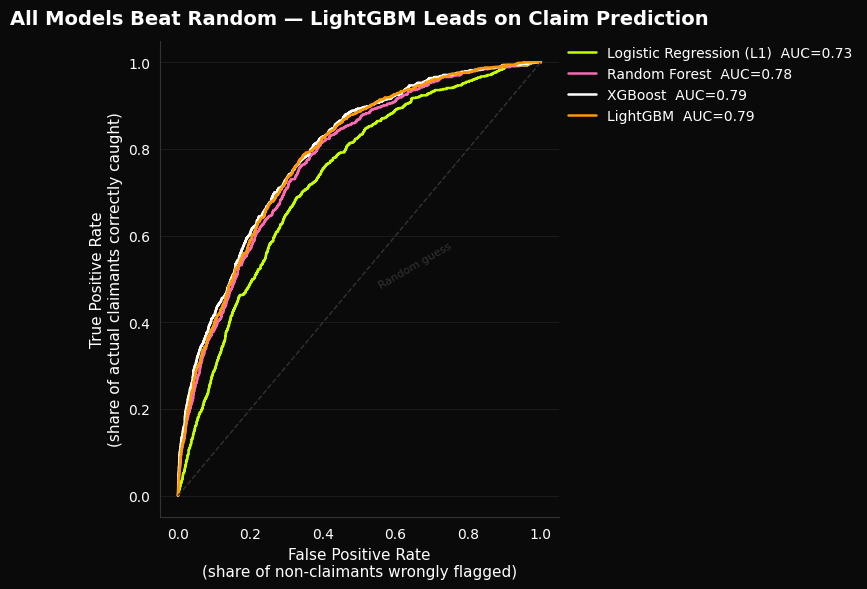

In [35]:
# ROC curve comparison
model_probas = {
    "Logistic Regression (L1)": y_proba_lr,
    "Random Forest":            y_proba_rf,
    "XGBoost":                  y_proba_xgb,
    "LightGBM":                 y_proba_lgb,
}
colors_roc = [LIME, PINK, WHITE, "#ff9900"]

fig, ax = plt.subplots(figsize=(8, 6))
for (name, y_proba), color in zip(model_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test_cs, y_proba)
    auc = roc_auc_score(y_test_cs, y_proba)
    ax.plot(fpr, tpr, label=f"{name}  AUC={auc:.2f}", color=color, linewidth=1.8)
ax.plot([0, 1], [0, 1], linestyle="--", color=GRAY, linewidth=1)
ax.text(0.55, 0.48, "Random guess", color=GRAY, fontsize=8, rotation=30)
ax.set_title("All Models Beat Random — LightGBM Leads on Claim Prediction", pad=12)
ax.set_xlabel("False Positive Rate\n(share of non-claimants wrongly flagged)")
ax.set_ylabel("True Positive Rate\n(share of actual claimants correctly caught)")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
apply_style(ax)
save_plot("roc_curve_comparison.png")


Accurate:      5240
Overpredicted:  1814
Underpredicted: 427


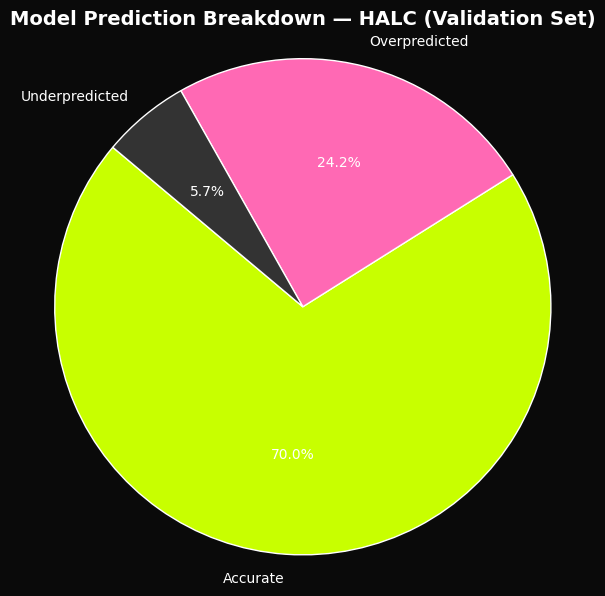

In [37]:
# Prediction breakdown pie chart — HALC
y_pred_all = final_lgbm.predict(X_val_halc)
tolerance  = 100

diff           = y_pred_all - y_val_halc.values[:len(y_pred_all)]
overpredicted  = (diff > tolerance).sum()
underpredicted = (diff < -tolerance).sum()
accurate       = ((diff >= -tolerance) & (diff <= tolerance)).sum()

print(f"Accurate:      {accurate}")
print(f"Overpredicted:  {overpredicted}")
print(f"Underpredicted: {underpredicted}")

labels = ['Accurate', 'Overpredicted', 'Underpredicted']
sizes  = [accurate, overpredicted, underpredicted]
colors_pie = [LIME, PINK, GRAY]

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(BG)
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie,
       startangle=140, textprops={'color': WHITE})
ax.set_title('Model Prediction Breakdown — HALC (Validation Set)', color=WHITE, pad=12)
ax.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'prediction_breakdown_pie.png'), dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

## 9. Task 2 — SHAP Feature Importance

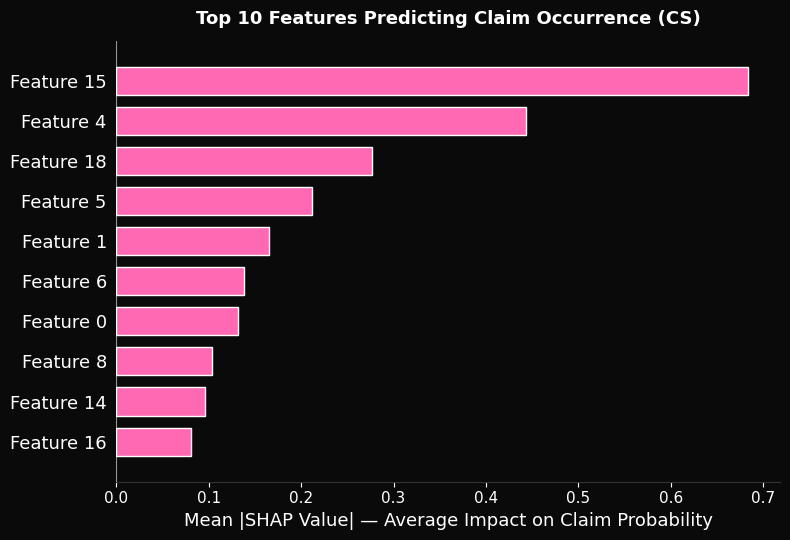

In [38]:
explainer_cs = shap.Explainer(lgb_clf)
shap_vals_cs = explainer_cs(X_train_s)

plt.rcParams.update({"text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE,
    "figure.facecolor": BG, "axes.facecolor": BG})

plt.figure(facecolor=BG)
shap.summary_plot(shap_vals_cs, X_train_s, plot_type="bar", show=False, max_display=10, color=PINK)
plt.gcf().set_facecolor(BG)
plt.gca().set_facecolor(BG)
plt.gca().tick_params(colors=WHITE)
plt.title("Top 10 Features Predicting Claim Occurrence (CS)", color=WHITE, pad=12, fontsize=13, fontweight="bold")
plt.xlabel("Mean |SHAP Value| — Average Impact on Claim Probability", color=WHITE)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_cs.png"), dpi=300, bbox_inches="tight", facecolor=BG)
plt.show()
plt.close()

## 10. Key Findings Summary

In [39]:
best_reg = results_df.iloc[0]
best_clf = clf_df.iloc[0]

print('=' * 70)
print('KEY FINDINGS SUMMARY')
print('=' * 70)
print(f"""
TASK 1 — REGRESSION (Loss Cost Prediction)
  Best model:  {best_reg['Model']}
  LC RMSE:     {best_reg['LC RMSE']:.2f}
  HALC RMSE:   {best_reg['HALC RMSE']:.2f}

  Model progression (HALC RMSE):""")
for _, row in results_df.iterrows():
    print(f"    {row['Model']:25s}  {row['HALC RMSE']:.2f}")

print(f"""
TASK 2 — CLASSIFICATION (Claim Occurrence)
  Best model:  {best_clf['Model']}
  ROC-AUC:     {best_clf['ROC-AUC']:.4f}

  All classifiers:""")
for _, row in clf_df.iterrows():
    print(f"    {row['Model']:30s}  AUC = {row['ROC-AUC']:.4f}")

print(f"""
SEGMENTATION
  Emerging policyholders (3-5 years) generate the highest average
  claims costs — more than new or long-term customers.
  Low-premium customers show disproportionately high claims costs
  relative to what they paid, suggesting the pricing model
  underestimates their risk.
""")

KEY FINDINGS SUMMARY

TASK 1 — REGRESSION (Loss Cost Prediction)
  Best model:  LightGBM
  LC RMSE:     285.91
  HALC RMSE:   564.08

  Model progression (HALC RMSE):
    LightGBM                   564.08
    Gradient Boosting          569.46
    Neural Network             569.81
    XGBoost                    569.93
    GLM Tweedie                573.65
    Random Forest              582.91

TASK 2 — CLASSIFICATION (Claim Occurrence)
  Best model:  XGBoost
  ROC-AUC:     0.7921

  All classifiers:
    XGBoost                         AUC = 0.7921
    LightGBM                        AUC = 0.7863
    Random Forest                   AUC = 0.7753
    Logistic Regression (L1)        AUC = 0.7306

SEGMENTATION
  Emerging policyholders (3-5 years) generate the highest average
  claims costs — more than new or long-term customers.
  Low-premium customers show disproportionately high claims costs
  relative to what they paid, suggesting the pricing model
  underestimates their risk.



## 11. Preview All Charts

Saved: ['model_comparison_halc.png', 'prediction_breakdown_pie.png', 'residuals_halc.png', 'roc_curve_comparison.png', 'segment_avg_halc.png', 'shap_cs.png', 'shap_halc.png']
--- model_comparison_halc.png ---


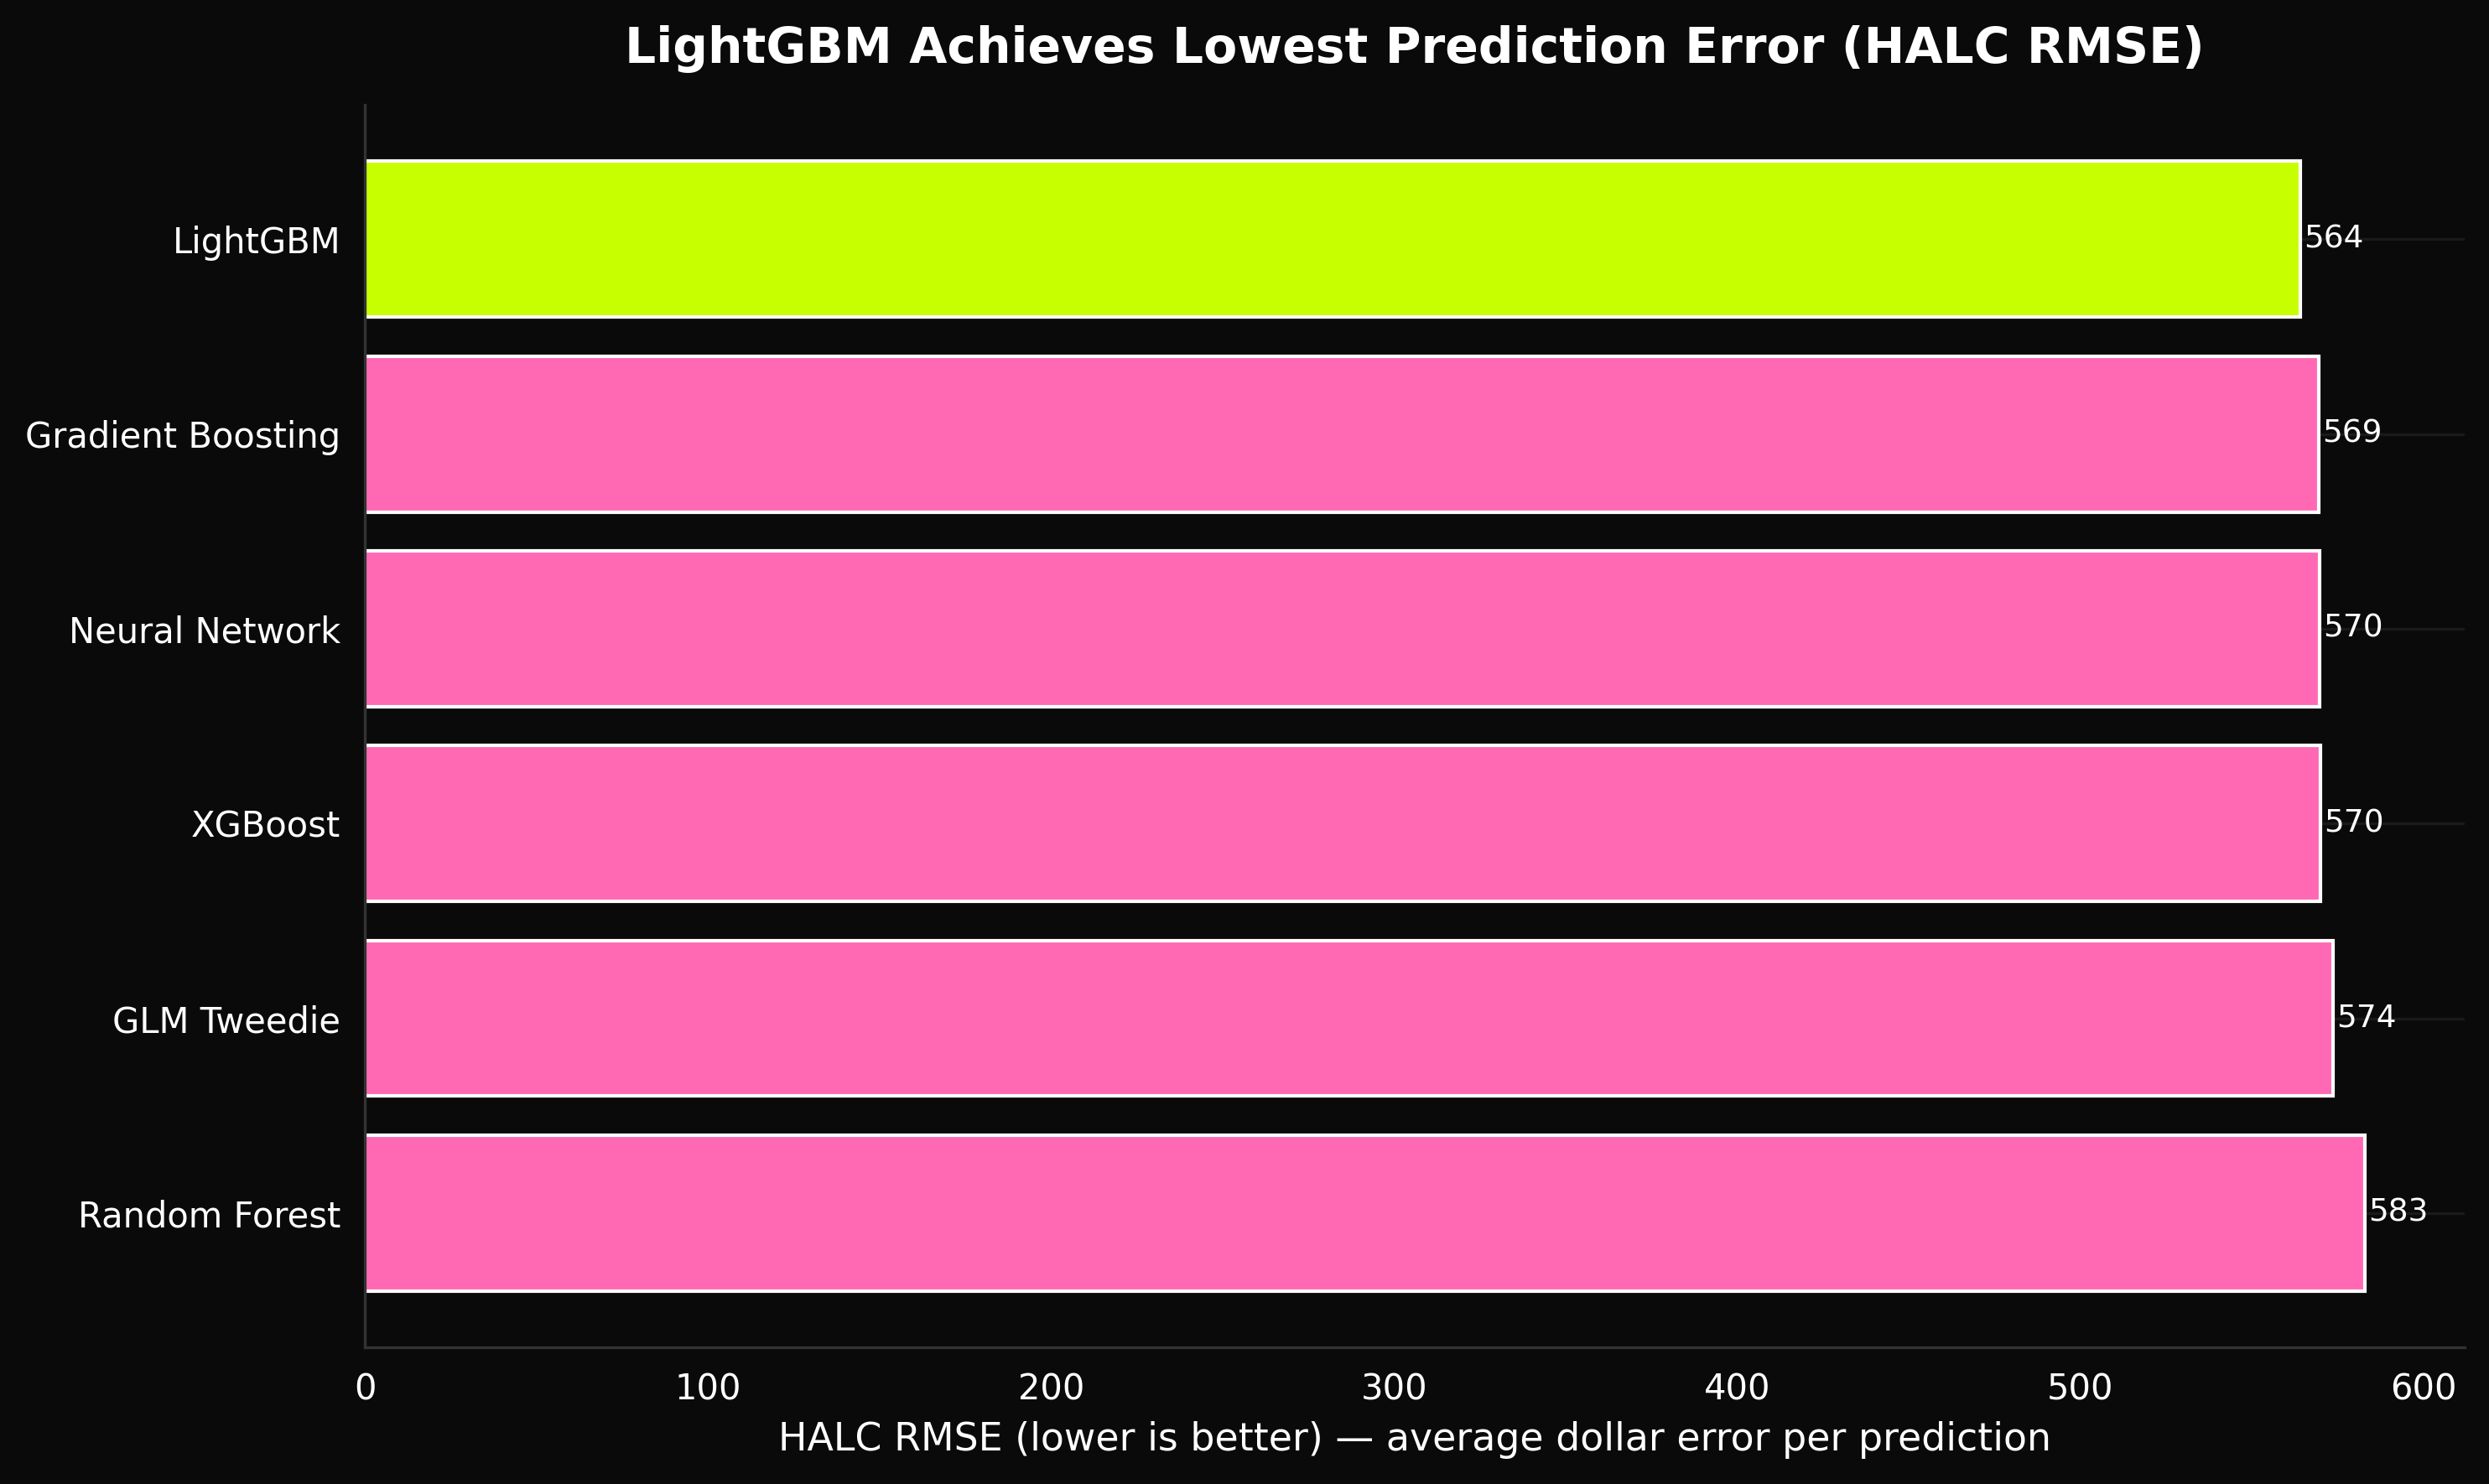

--- residuals_halc.png ---


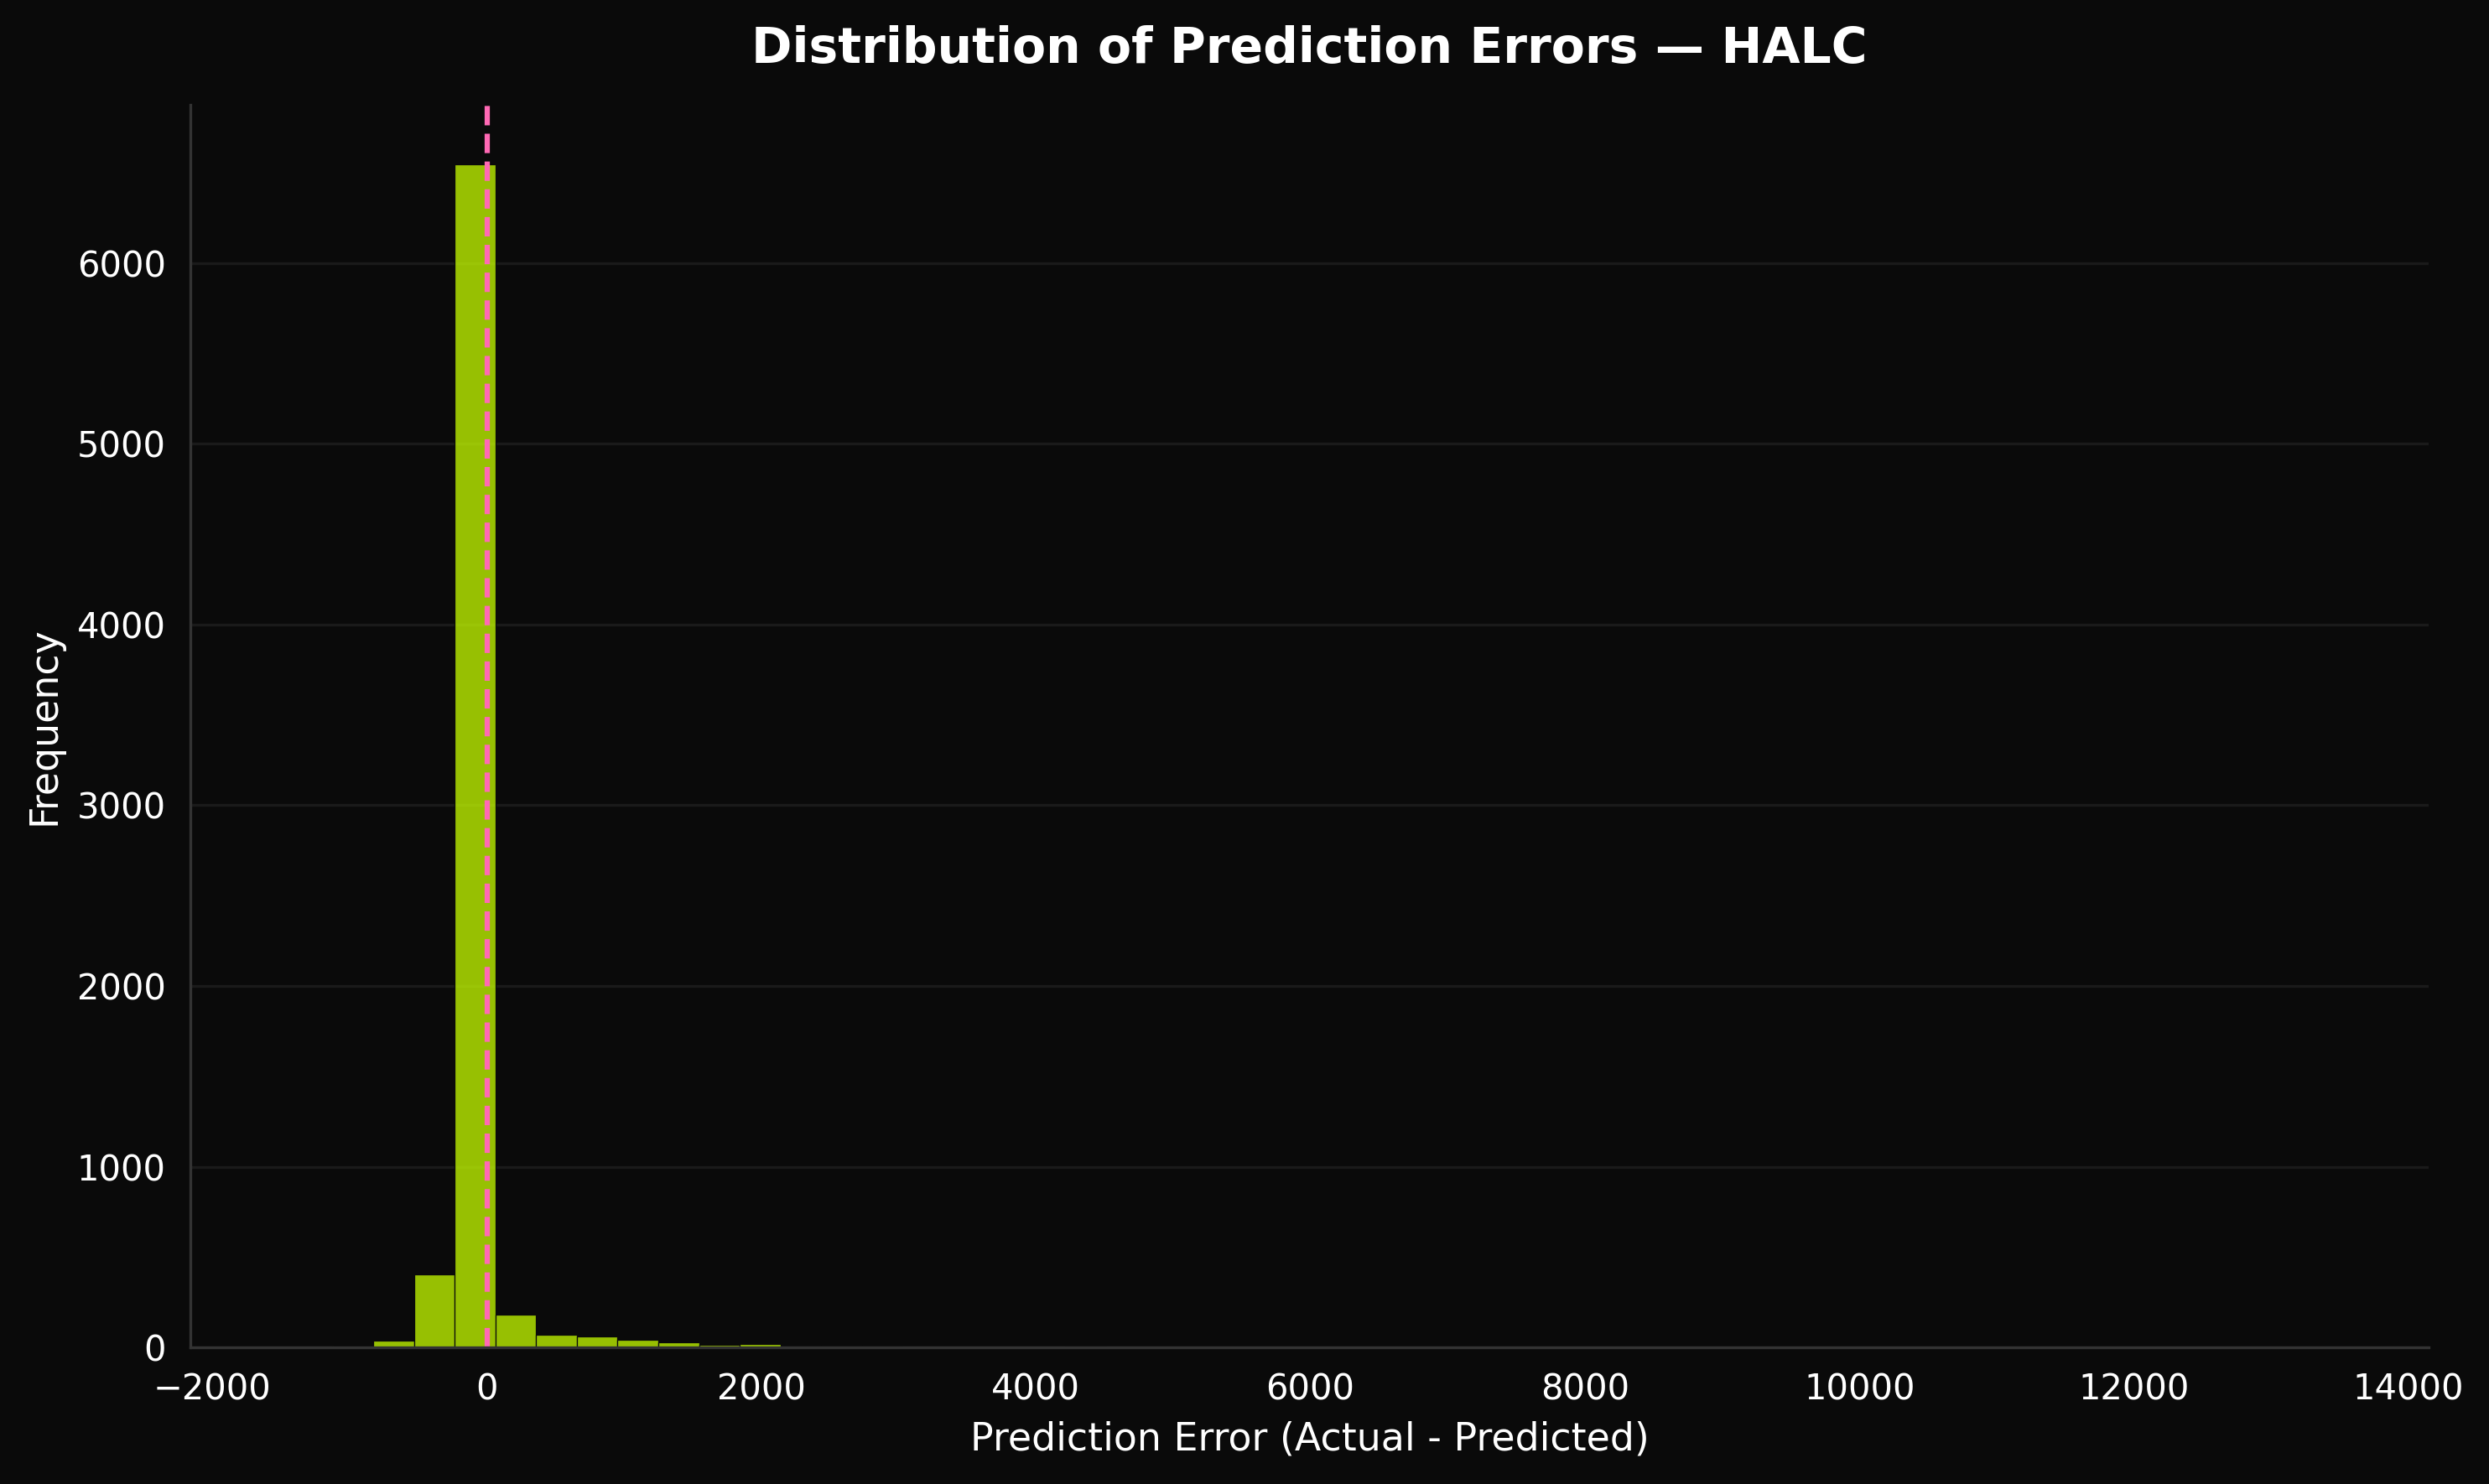

--- shap_halc.png ---


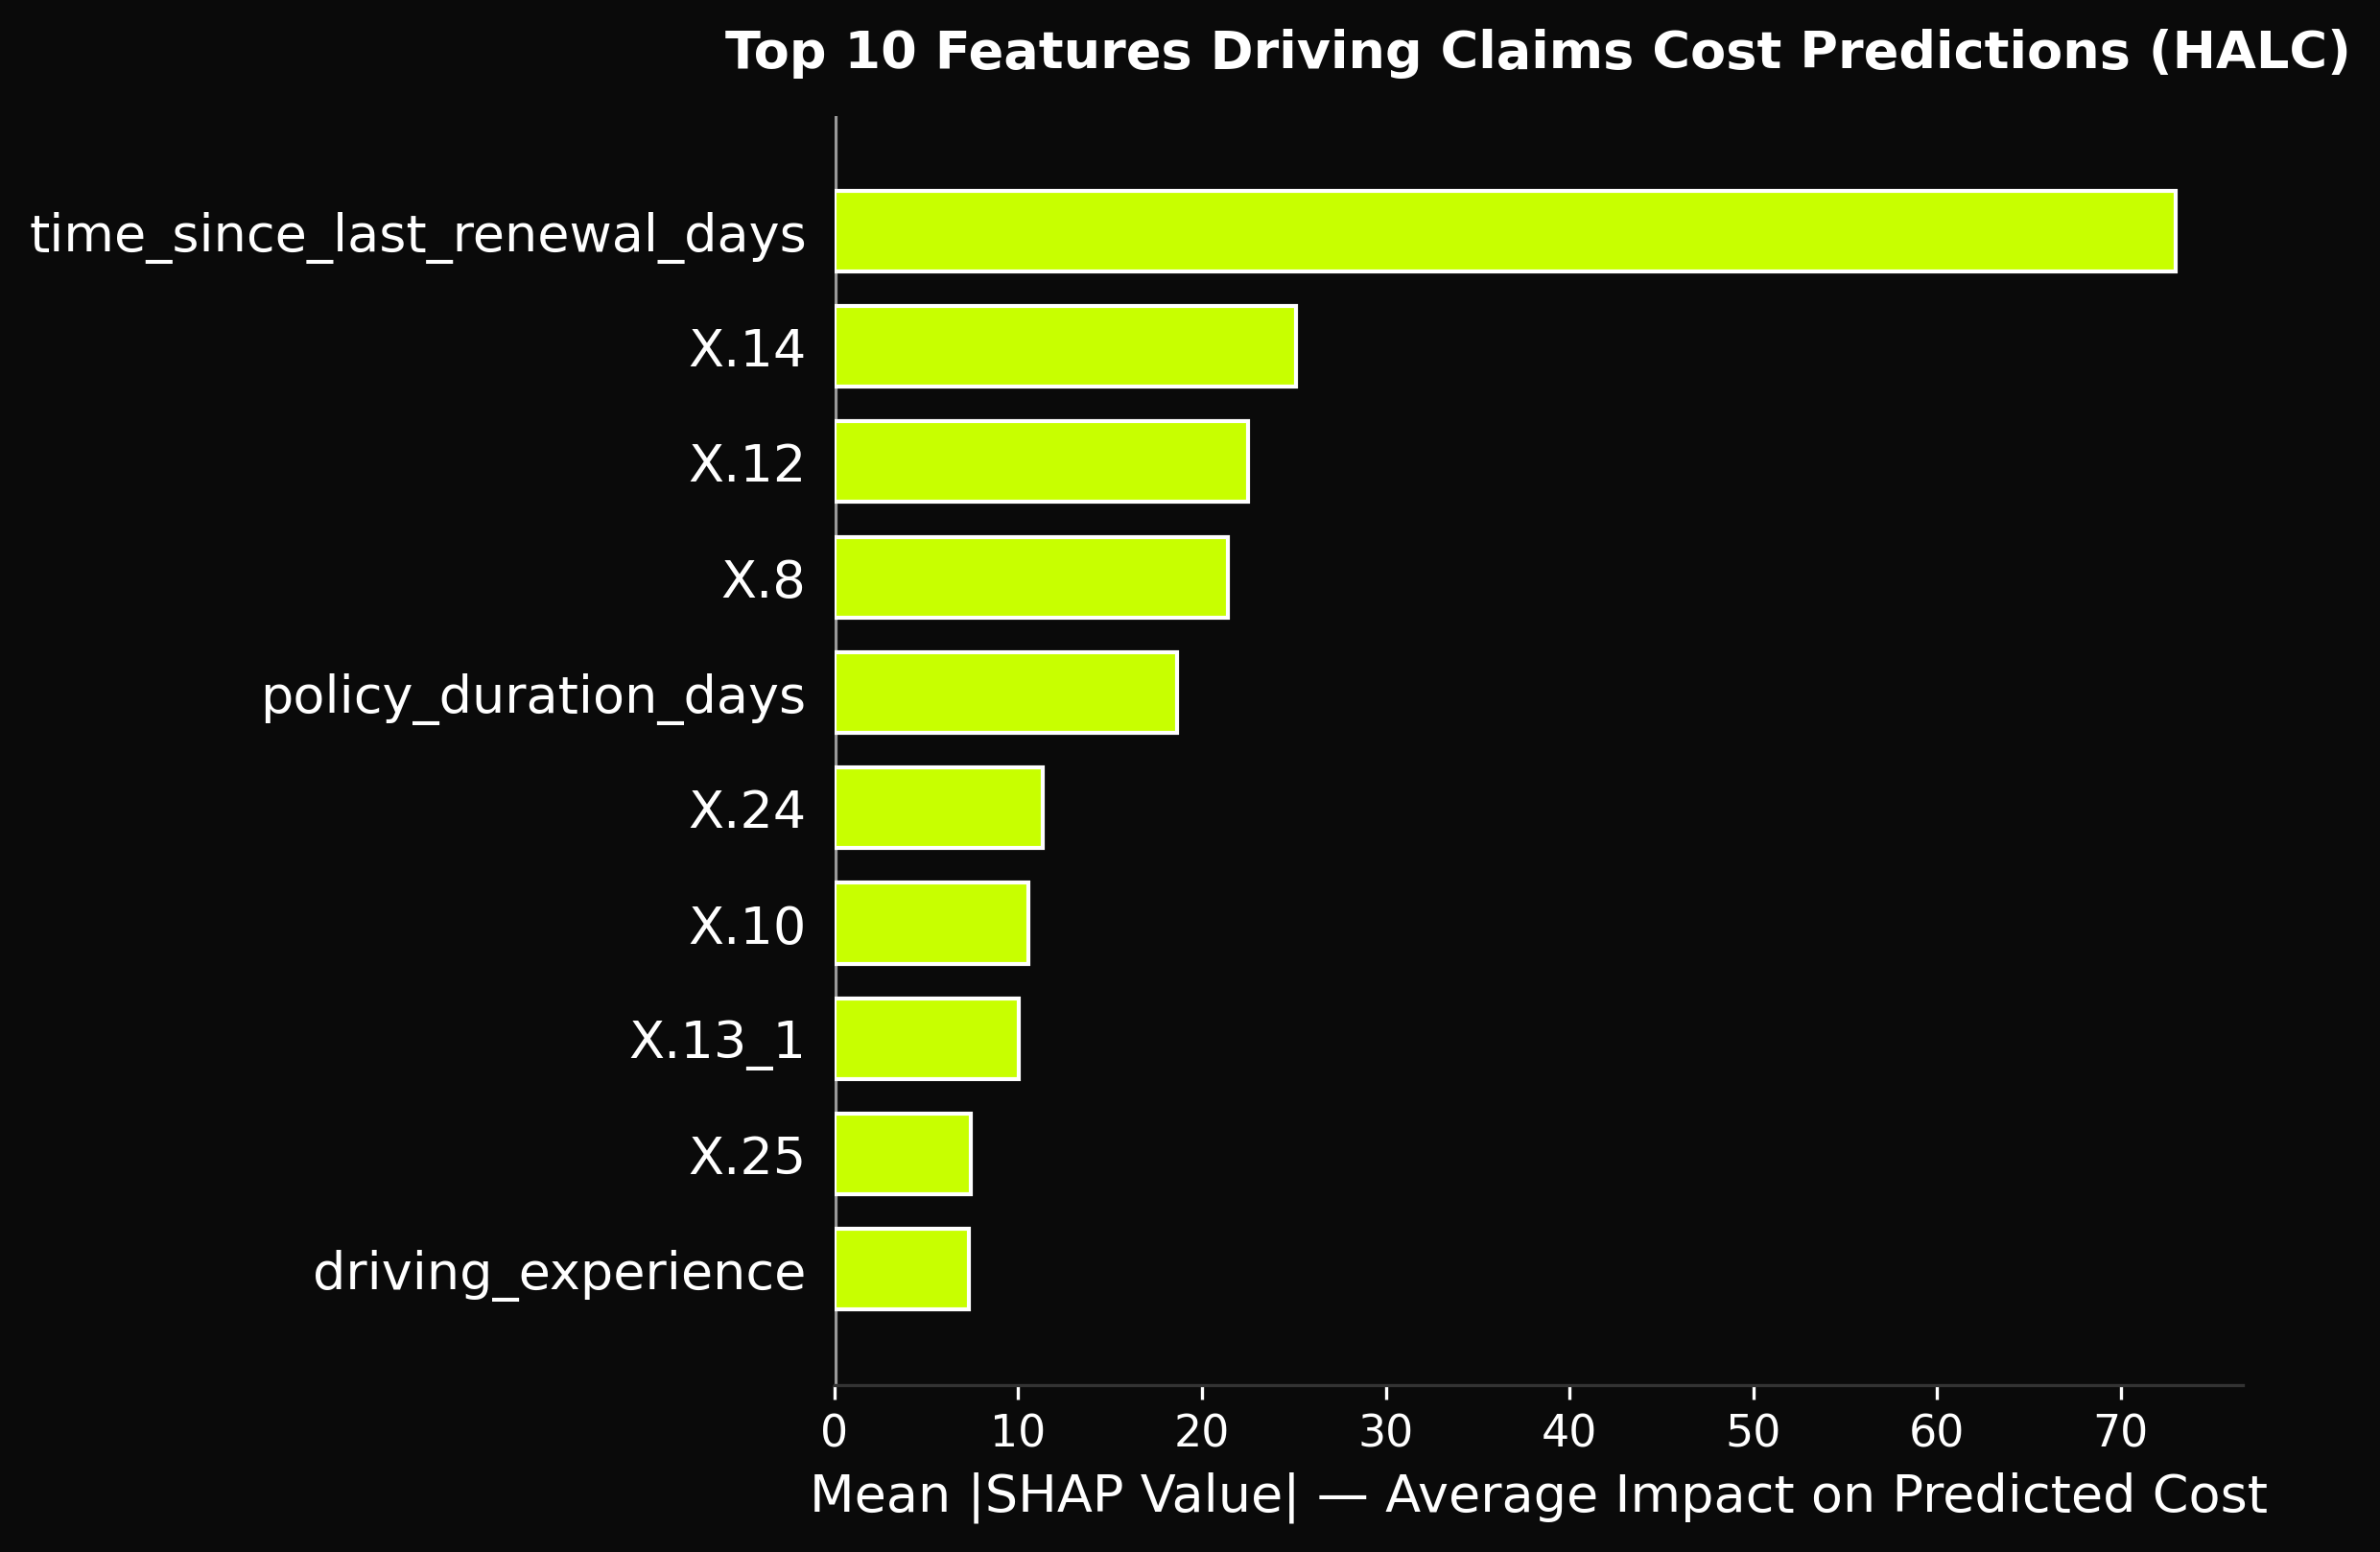

--- segment_avg_halc.png ---


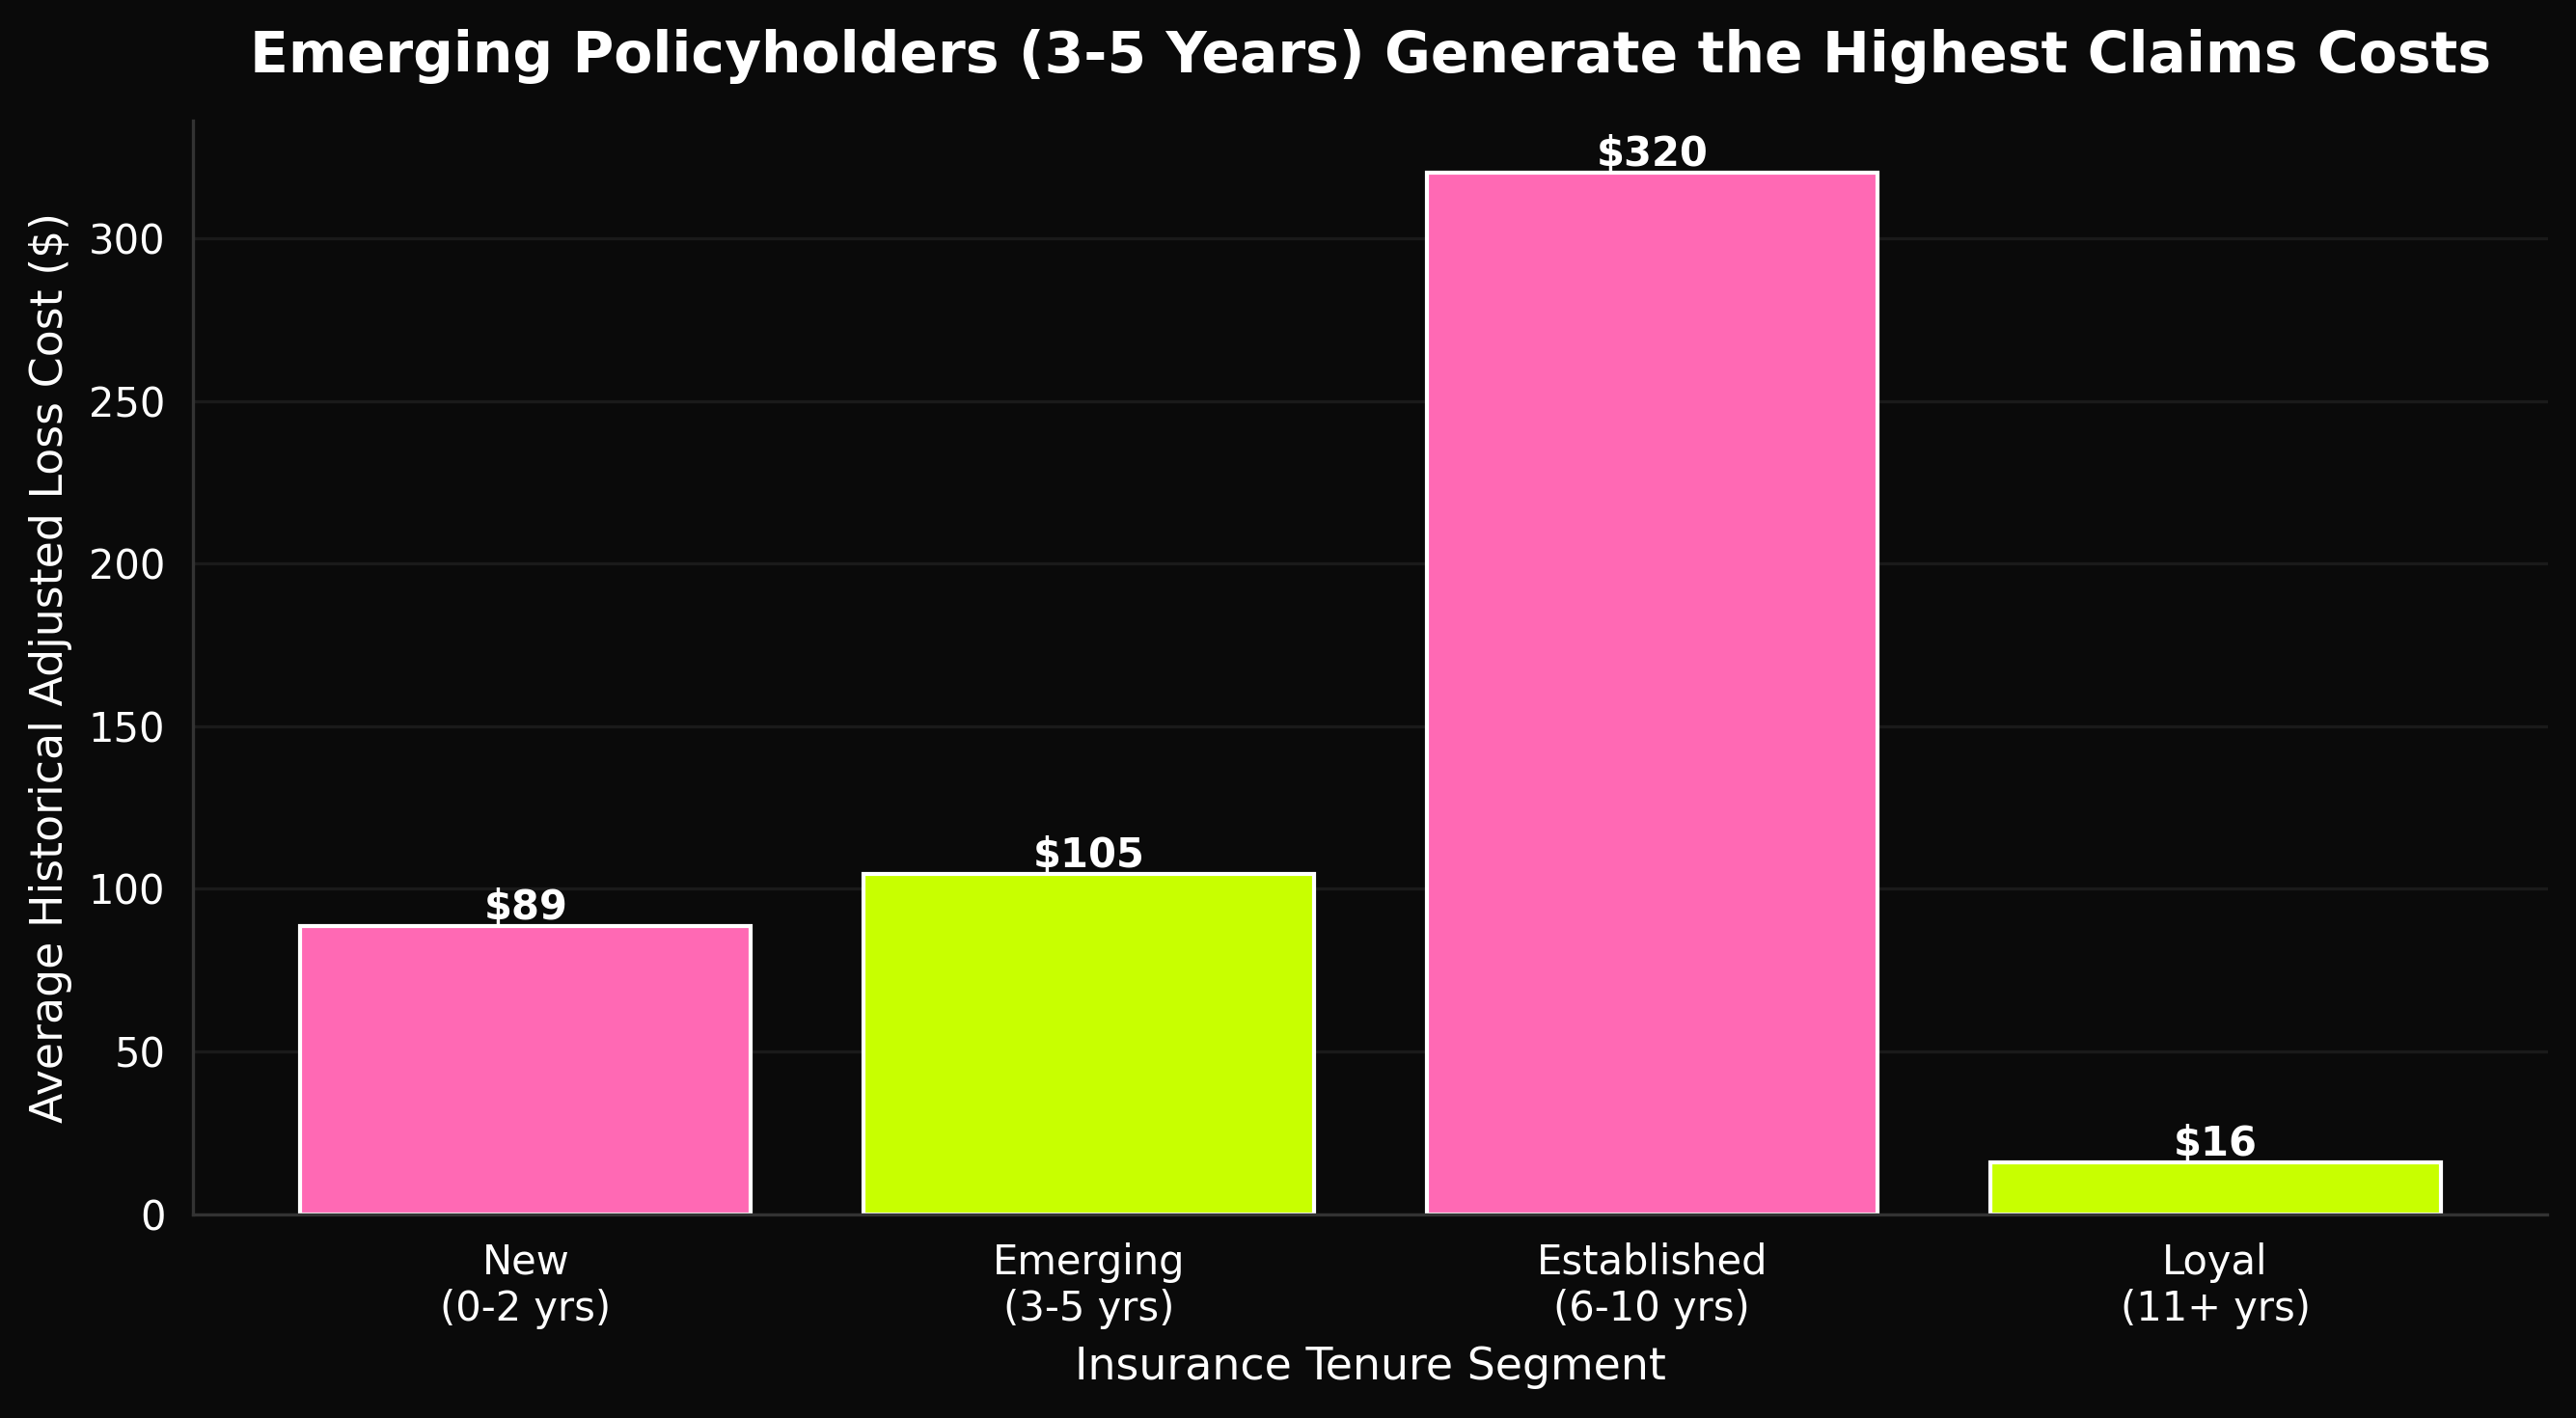

--- roc_curve_comparison.png ---


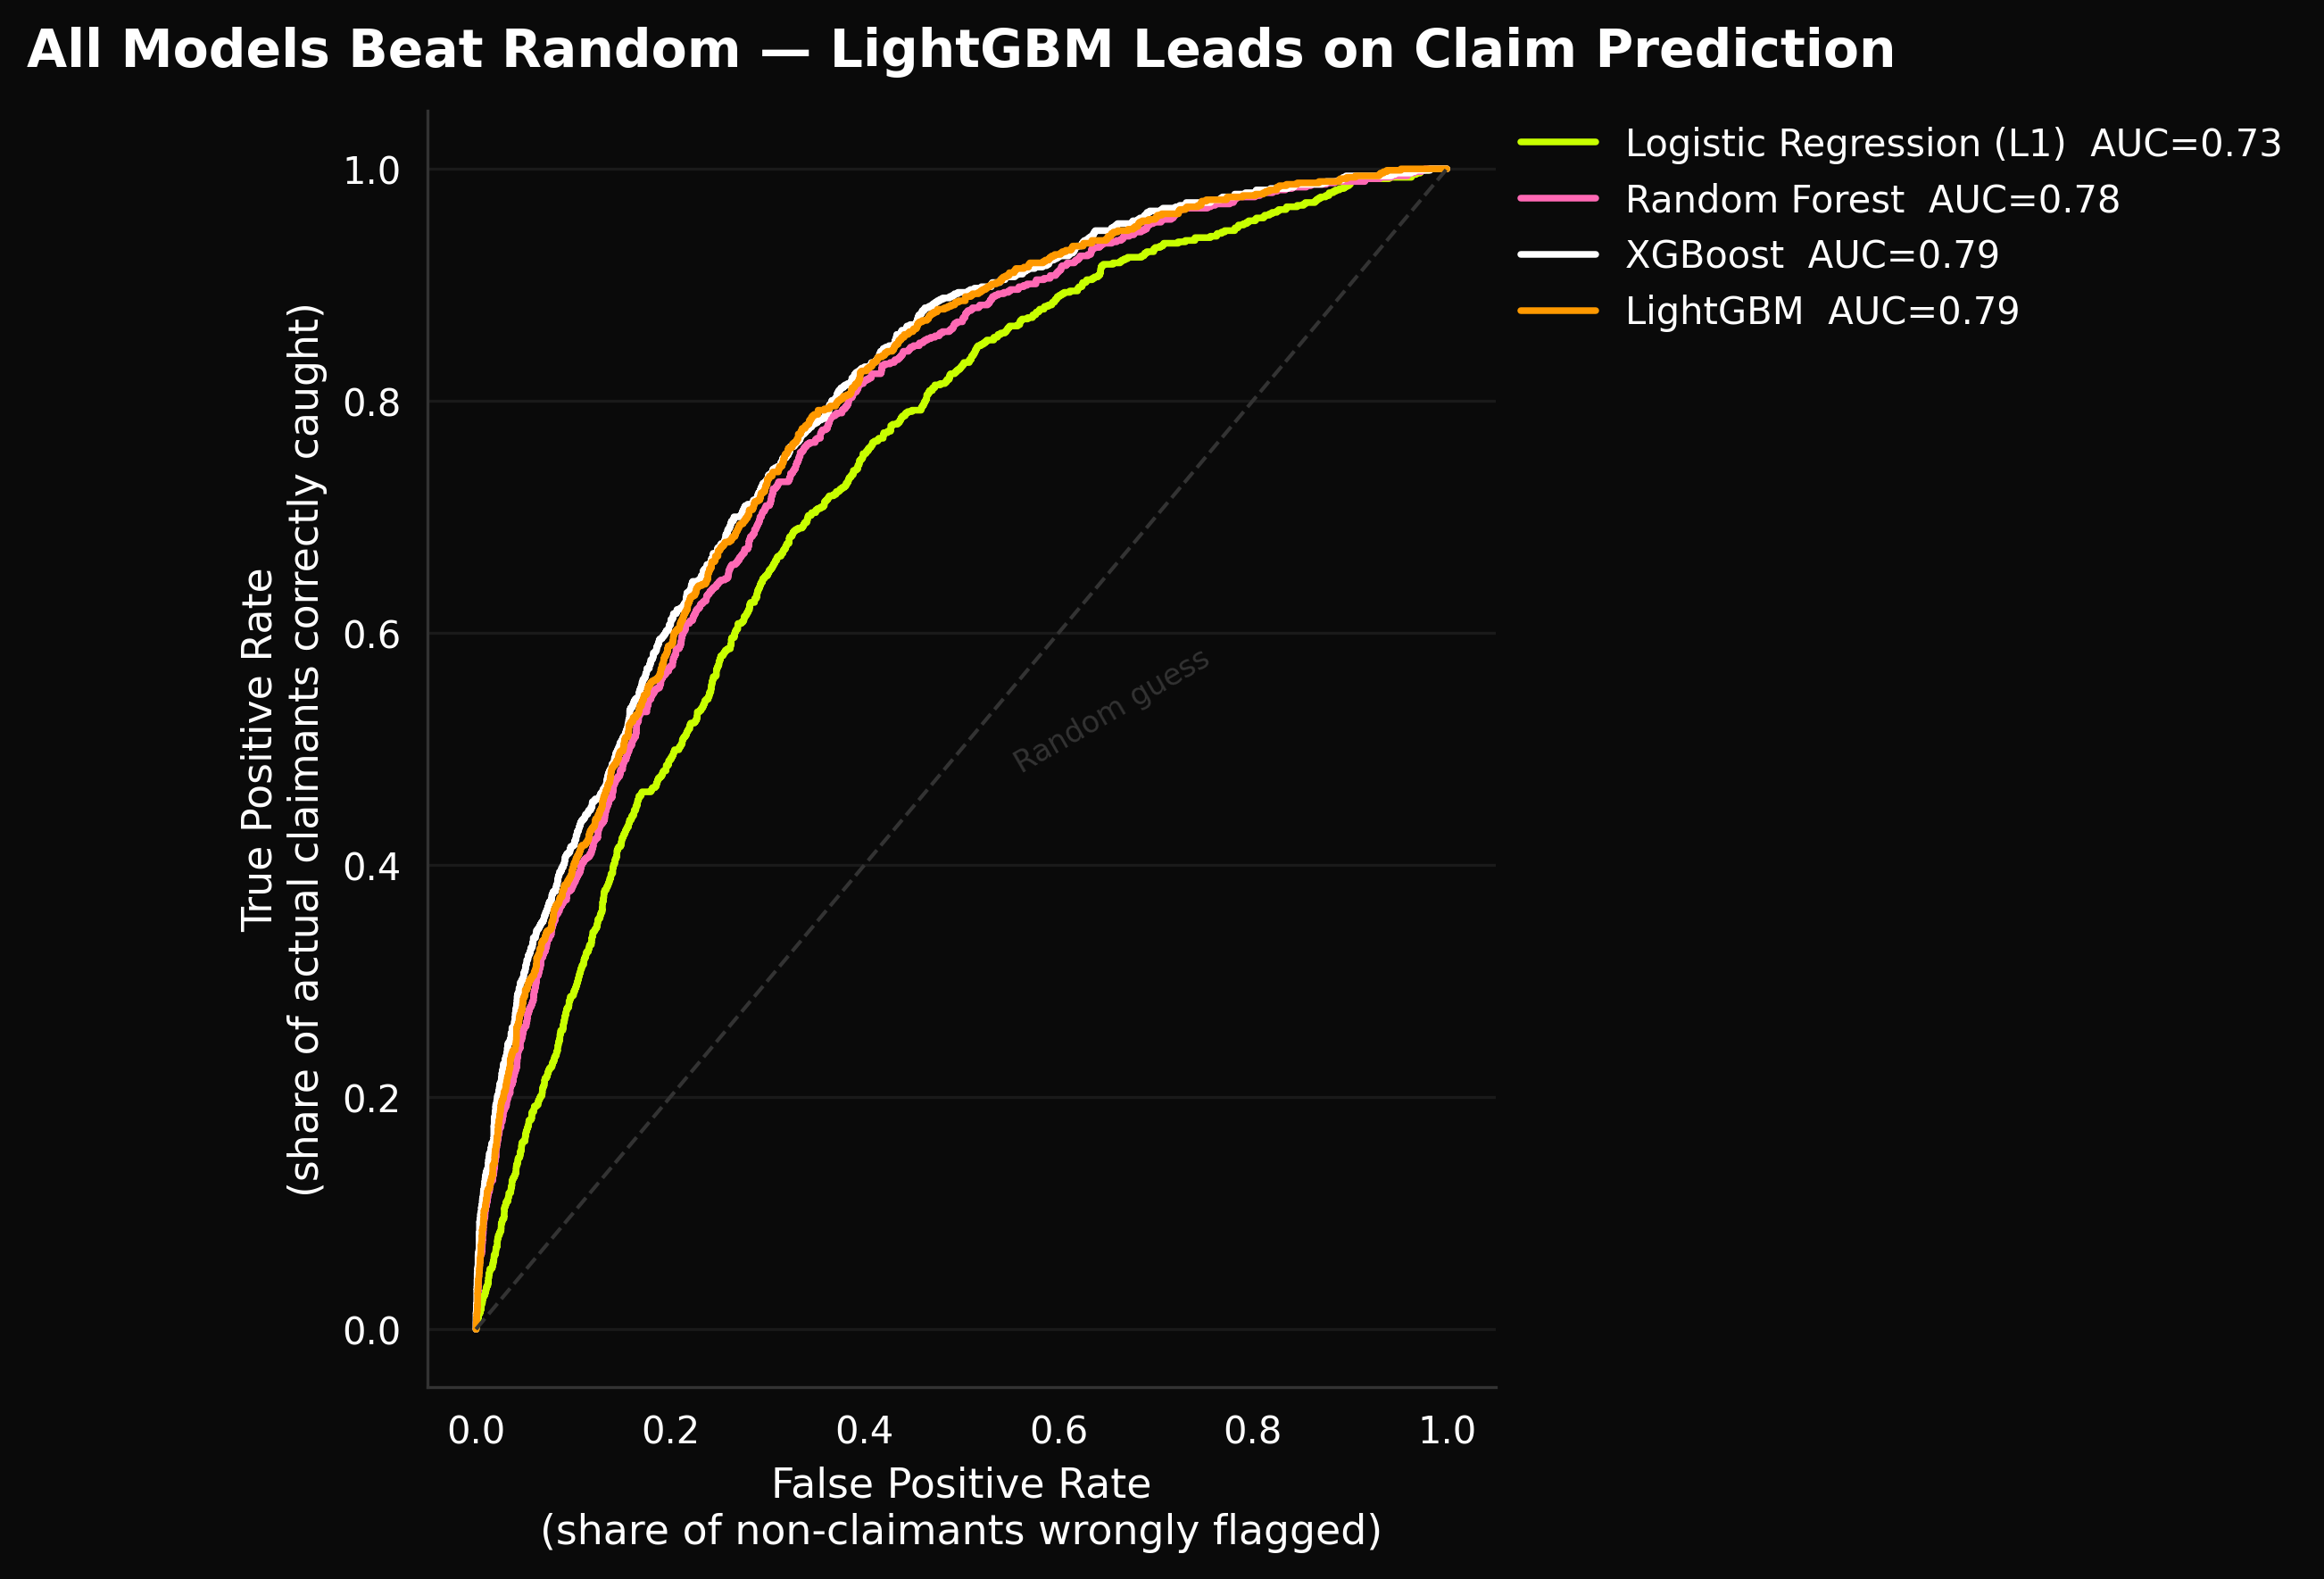

--- prediction_breakdown_pie.png ---


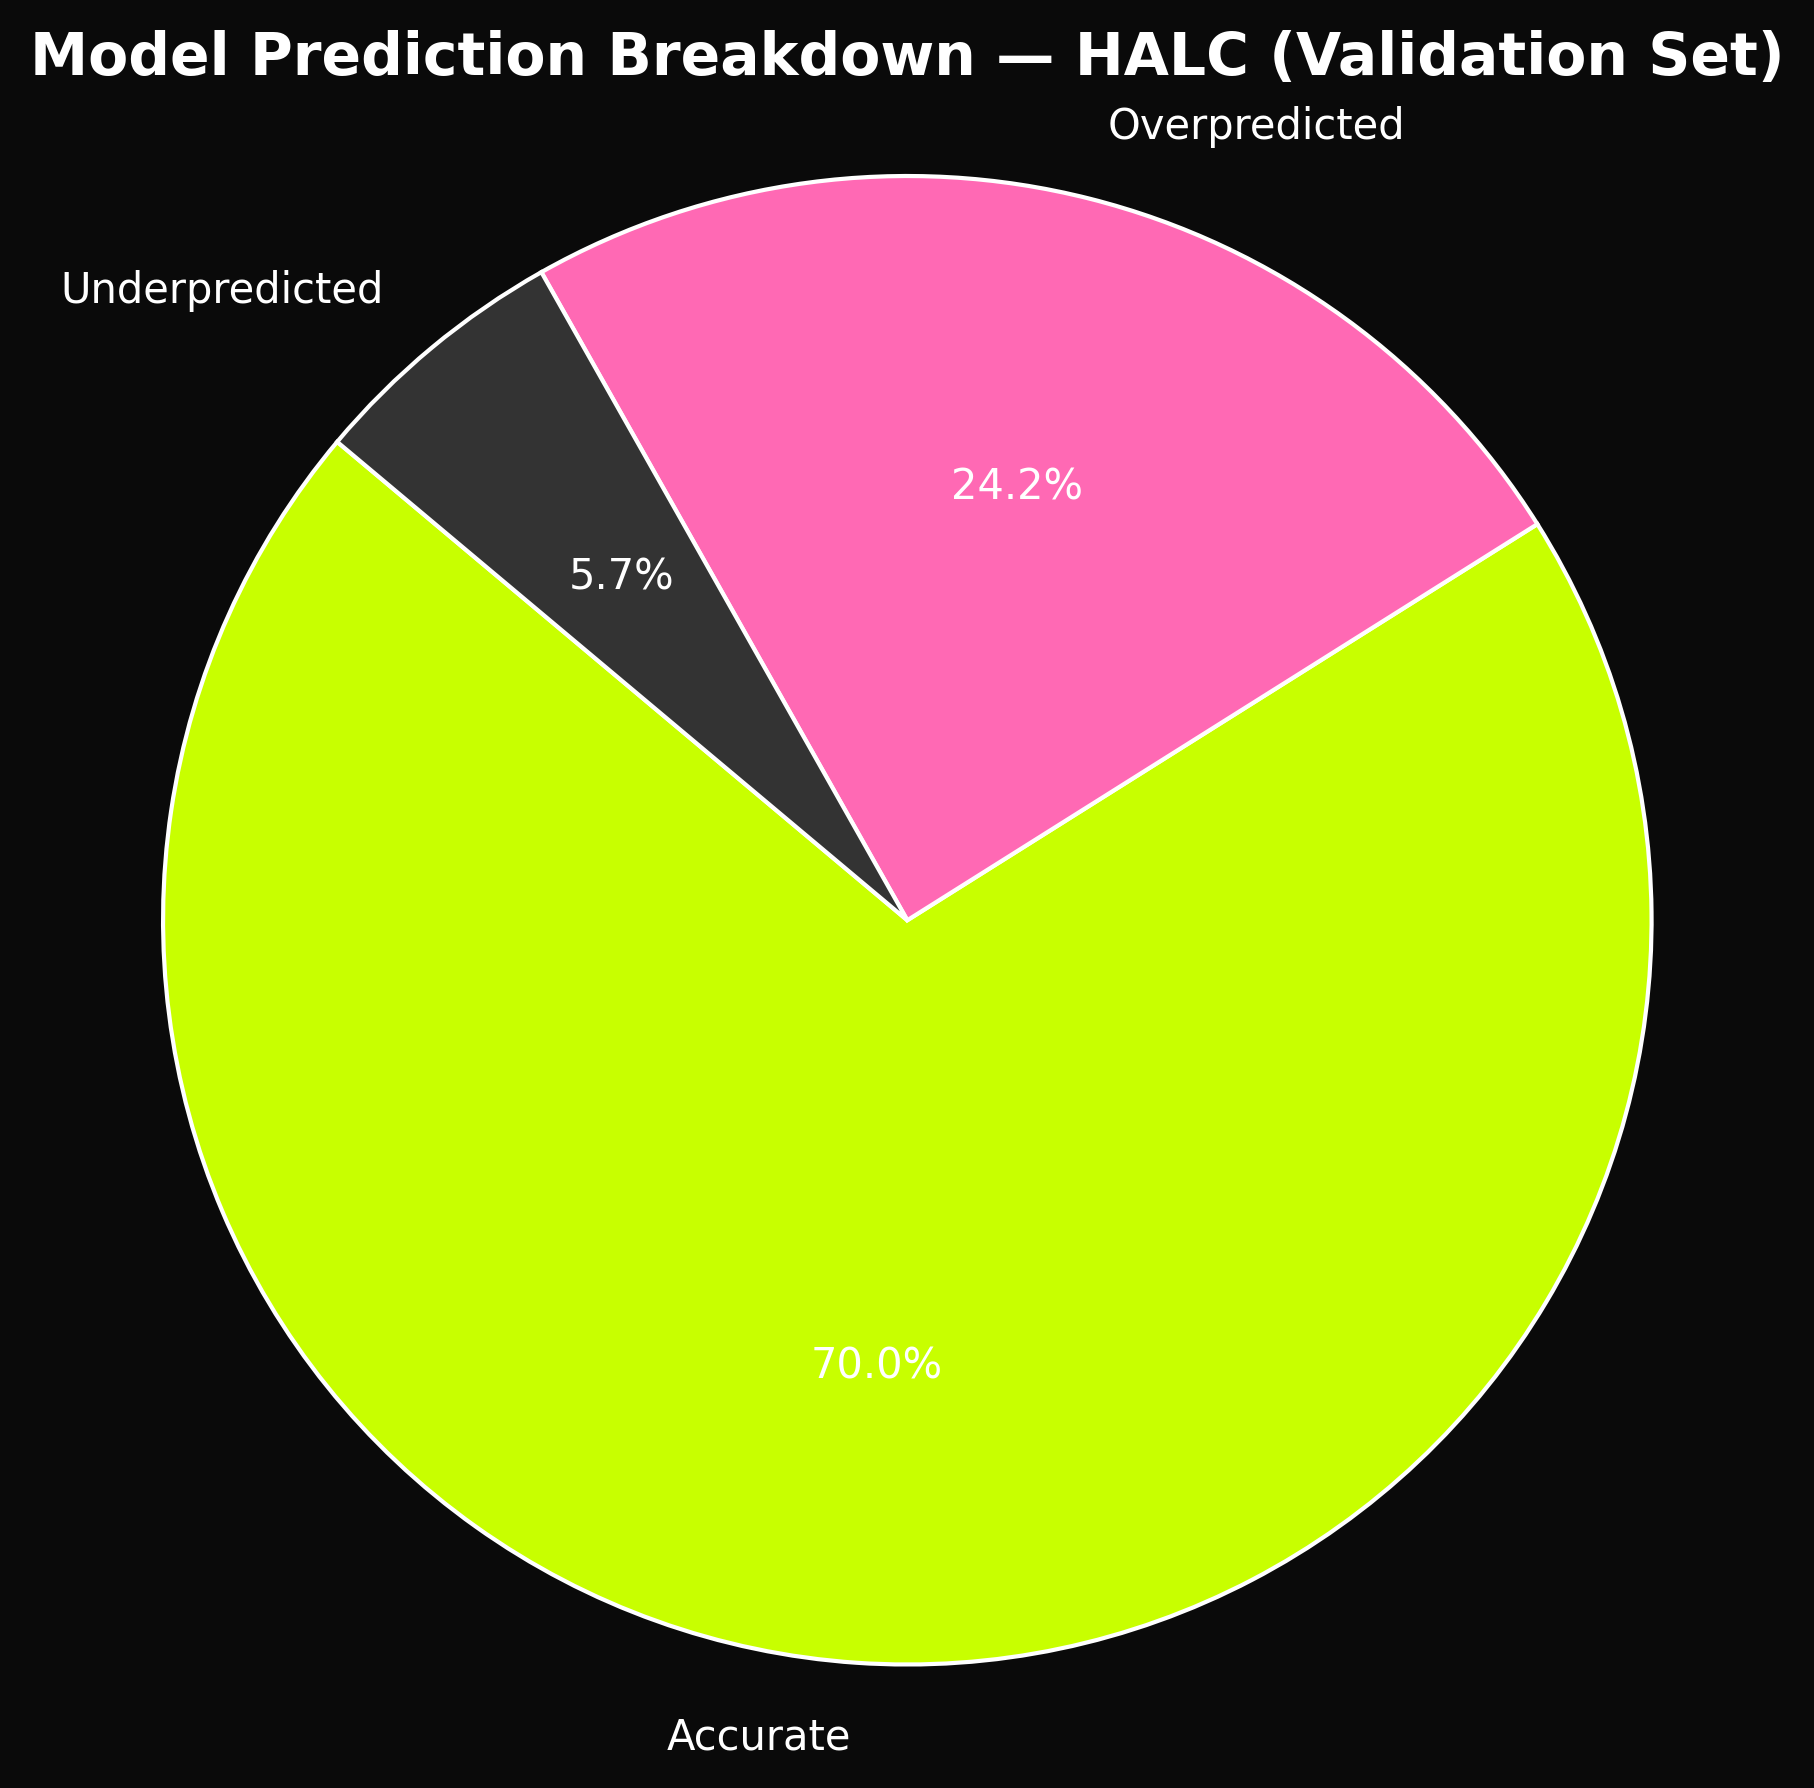

--- shap_cs.png ---


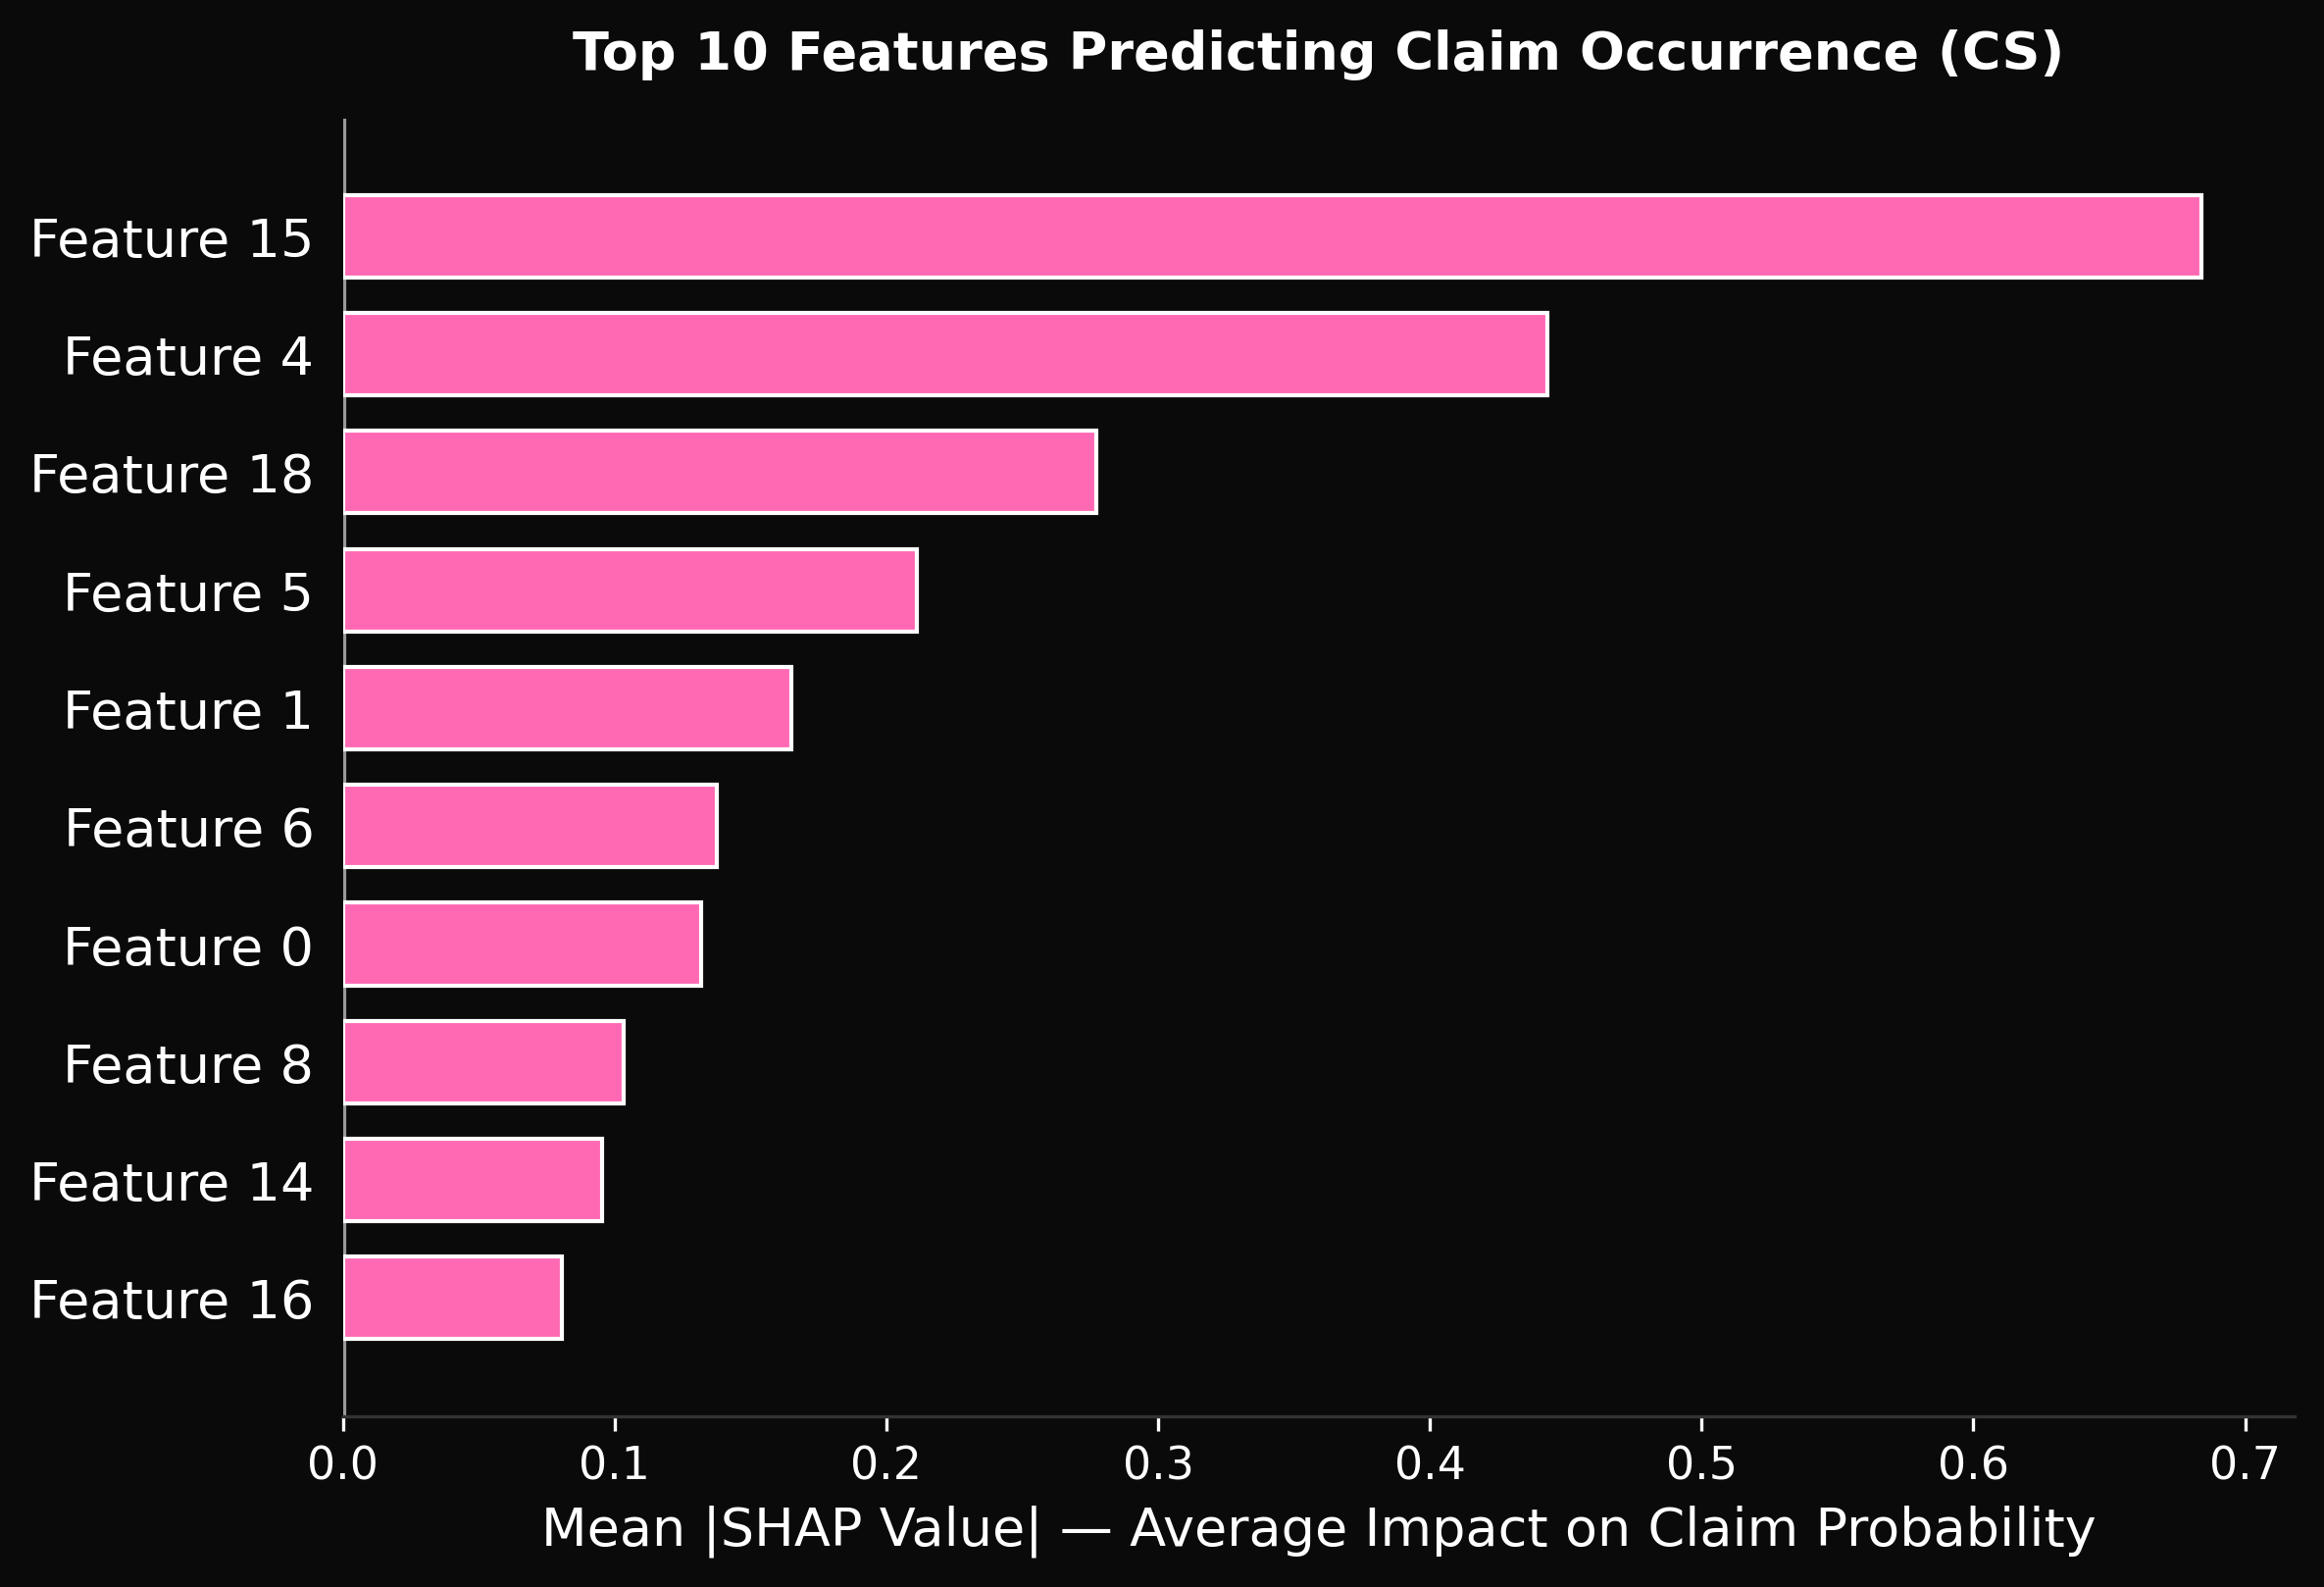

In [40]:
charts = [
    'model_comparison_halc.png',
    'predicted_vs_actual_halc.png',
    'residuals_halc.png',
    'residuals_vs_predicted_halc.png',
    'predicted_vs_actual_lc.png',
    'residuals_lc.png',
    'residuals_vs_predicted_lc.png',
    'shap_halc.png',
    'segment_avg_halc.png',
    'class_distribution.png',
    'roc_curve_comparison.png',
    'prediction_breakdown_pie.png',
    'shap_cs.png'
]
print(f'Saved: {sorted(os.listdir(PLOTS_DIR))}')
for chart in charts:
    path = os.path.join(PLOTS_DIR, chart)
    if os.path.exists(path):
        print(f'--- {chart} ---')
        display(Image(filename=path))
